# 02 – Exploratory Data Analysis (EDA)

## 0. Import Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from pandas.plotting import parallel_coordinates
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

PALETTE   = {0: '#4CAF50', 1: '#E53935'}   # hijau=normal, merah=defect
LABEL_MAP = {0: 'Normal', 1: 'Defect'}

print('Library berhasil diimport ✓')

Library berhasil diimport ✓


In [2]:
df = pd.read_csv('outputs/dataset_clean.csv')
df['is_defect'] = df['is_defect'].astype(int)

print(f'Shape dataset  : {df.shape}')
print(f'Distribusi label:')
vc = df['is_defect'].value_counts().rename(index=LABEL_MAP)
for k, v in vc.items():
    print(f'  {k:8s}: {v} ({v/len(df)*100:.1f}%)')
df.head(3)

Shape dataset  : (46, 135)
Distribusi label:
  Normal  : 35 (76.1%)
  Defect  : 11 (23.9%)


,material_desc,batch_ke,lapis1_warna,cb1_bulan,cb1_shift,cb1_line,cb1_jml_decoct_kg,cb1_suhu_lot1_1,cb1_suhu_lot1_2,cb1_suhu_lot2_1,...,cb2_suhu_tinggi,no_batch_num,lapis1_warna_enc,lapis2_warna_enc,cb1_bulan_num,cb2_bulan_num,cb1_line_enc,cb2_line_enc,ck1_keterangan_selesai,ck2_keterangan_selesai
0,BODREX FLU & BATUK PE/4'S,1.0,Orange,DESEMBER,1,CB 1,76.0,71.6,71.2,71.9,...,0,0,0,0,12,12,0,1,1,1
1,BODREX FLU & BATUK PE/4'S,5.5,Orange,DESEMBER,1,CB 1,114.0,80.4,80.9,71.1,...,0,0,0,0,12,0,0,-1,1,0
2,BODREX FLU & BATUK PE/4'S,2.0,Orange,DESEMBER,1,CB 1,76.0,71.3,71.5,71.0,...,0,0,0,0,12,12,0,1,1,1


---
## 1. Gambaran Umum Dataset

In [3]:
print('=' * 55)
print('  RINGKASAN DATASET')
print('=' * 55)
print(f'  Jumlah baris (batch)   : {len(df)}')
print(f'  Jumlah kolom/fitur     : {len(df.columns)}')
print(f'  Batch Normal (label=0) : {(df.is_defect==0).sum()}')
print(f'  Batch Defect (label=1) : {(df.is_defect==1).sum()}')
print(f'  Rasio defect           : {df.is_defect.mean()*100:.1f}%')
print(f'  Produk unik            : {df["material_desc"].nunique()}')
print('=' * 55)

  RINGKASAN DATASET
  Jumlah baris (batch)   : 46
  Jumlah kolom/fitur     : 135
  Batch Normal (label=0) : 35
  Batch Defect (label=1) : 11
  Rasio defect           : 23.9%
  Produk unik            : 1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Columns: 135 entries, material_desc to ck2_keterangan_selesai
dtypes: float64(96), int32(1), int64(29), object(9)
memory usage: 48.5+ KB


In [5]:
# Missing value
missing = df.isnull().sum()
missing_pct = missing / len(df) * 100
mv_df = pd.DataFrame({'Missing': missing, 'Missing (%)': missing_pct.round(2)})
mv_df = mv_df[mv_df['Missing'] > 0].sort_values('Missing (%)', ascending=False)
print(f'Kolom dengan missing value: {len(mv_df)} dari {len(df.columns)}')
if len(mv_df):
    print(mv_df.to_string())
else:
    print('  ✅ Tidak ada missing value.')

Kolom dengan missing value: 0 dari 135
  ✅ Tidak ada missing value.


In [6]:
# Duplicate & constant columns
print(f'Baris duplikat : {df.duplicated().sum()}')
const_cols = [c for c in df.columns if df[c].nunique() == 1]
print(f'Kolom konstan  : {len(const_cols)}')
if const_cols:
    for c in const_cols:
        print(f'  - {c}: {df[c].iloc[0]}')

Baris duplikat : 0
Kolom konstan  : 26
  - material_desc: BODREX FLU & BATUK PE/4'S
  - lapis1_warna: Orange
  - cb1_teoritis_granul: 299.0
  - cb1_no_ayakan_alex: 52.0
  - cb1_no_ayakan_frewitt: 1.5
  - ck1_teoritis_granul: 315.0
  - lapis2_warna: KUNING
  - cb2_jml_decoct_kg: 200.0
  - cb2_teoritis_granul: 531.53
  - cb2_no_ayakan_alex: 52.0
  - cb2_no_ayakan_frewitt: 1.5
  - cb1_ka1_ekstrem: 0
  - cb1_ka3_ekstrem: 0
  - cb1_ka4_ekstrem: 0
  - cb2_ka1_ekstrem: 0
  - cb2_ka2_ekstrem: 0
  - cb2_ka3_ekstrem: 0
  - cb2_ka4_ekstrem: 0
  - ck1_ka_setelah_ck_ekstrem: 0
  - ck2_ka_setelah_ck_ekstrem: 0
  - cb1_ka_outlier: 0
  - cb2_ka_outlier: 0
  - cb2_suhu_tinggi: 0
  - no_batch_num: 0
  - lapis1_warna_enc: 0
  - lapis2_warna_enc: 0


In [7]:
# Statistik deskriptif kolom kunci
key_num = ['cb1_suhu_rata','cb2_suhu_rata','cb1_rata_ka','cb2_rata_ka',
           'cb1_pct_yield','cb2_pct_yield','ck1_pct_yield',
           'ck1_ka_setelah_ck']
key_num = [c for c in key_num if c in df.columns]
df[key_num].describe().round(3)

,cb1_suhu_rata,cb2_suhu_rata,cb1_rata_ka,cb2_rata_ka,cb1_pct_yield,cb2_pct_yield,ck1_pct_yield,ck1_ka_setelah_ck
count,46.000,46.000,46.000,46.000,46.000,46.000,46.000,46.000
mean,74.536,71.643,4.966,3.359,100.745,98.860,99.549,4.716
std,1.595,0.261,0.076,0.050,7.757,14.923,15.056,0.256
min,71.380,71.100,4.750,3.242,50.679,0.000,0.000,4.010
25%,73.850,71.490,4.932,3.336,101.482,100.335,101.492,4.610
50%,74.140,71.610,4.985,3.358,102.212,101.213,102.064,4.735
75%,74.600,71.690,5.019,3.384,102.567,101.706,102.381,4.807
max,79.450,72.360,5.060,3.465,106.120,102.265,103.587,5.570


---
## 2. Distribusi Label Defect

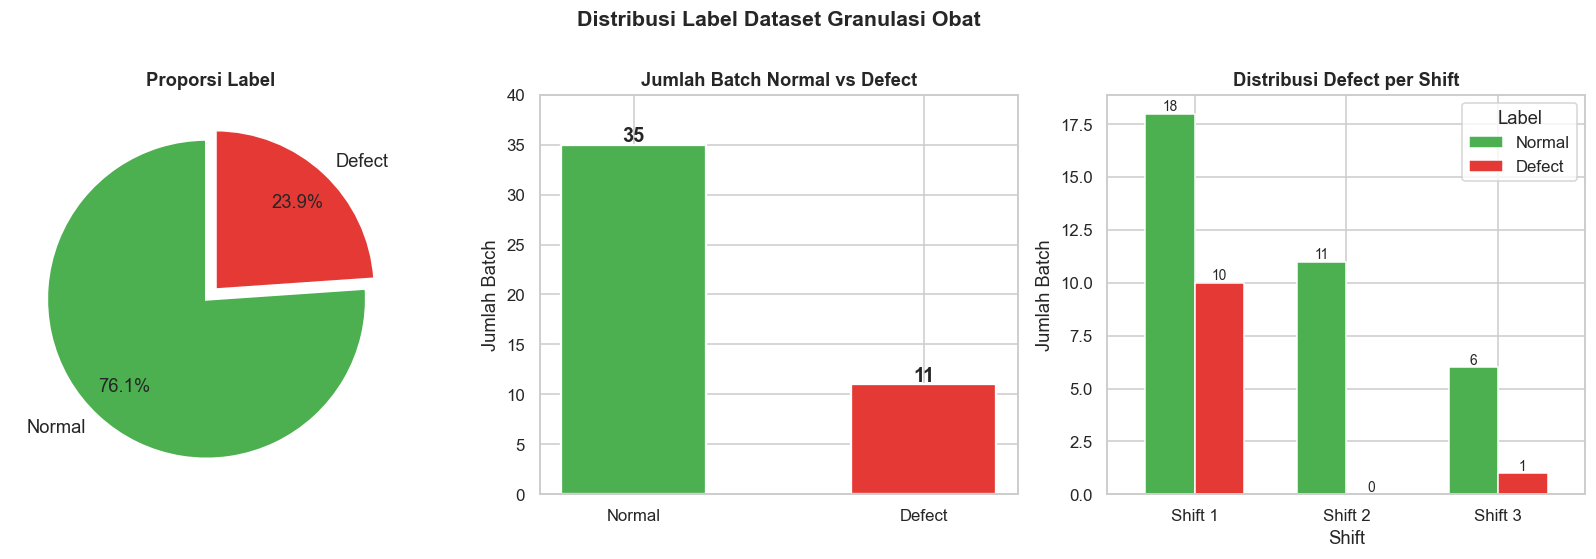

Catatan: Dataset imbalanced → gunakan class_weight='balanced' atau SMOTE saat modeling.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribusi Label Dataset Granulasi Obat',
             fontsize=14, fontweight='bold', y=1.01)

counts = df['is_defect'].value_counts().sort_index()
colors = [PALETTE[i] for i in counts.index]

# Pie
axes[0].pie(counts, labels=[LABEL_MAP[i] for i in counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90,
            explode=(0.04, 0.04),
            textprops={'fontsize': 12}, pctdistance=0.75,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Proporsi Label', fontweight='bold')

# Bar jumlah
bars = axes[1].bar([LABEL_MAP[i] for i in counts.index], counts.values,
                   color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Jumlah Batch')
axes[1].set_title('Jumlah Batch Normal vs Defect', fontweight='bold')
axes[1].set_ylim(0, max(counts.values) + 5)

# Bar per shift
shift_cross = df.groupby(['cb1_shift', 'is_defect']).size().unstack(fill_value=0)
shift_cross.columns = ['Normal', 'Defect']
shift_cross.plot(kind='bar', ax=axes[2], color=[PALETTE[0], PALETTE[1]],
                 edgecolor='white', width=0.65)
axes[2].set_title('Distribusi Defect per Shift', fontweight='bold')
axes[2].set_xlabel('Shift')
axes[2].set_ylabel('Jumlah Batch')
axes[2].set_xticklabels([f'Shift {s}' for s in shift_cross.index], rotation=0)
axes[2].legend(title='Label')
for container in axes[2].containers:
    axes[2].bar_label(container, fontsize=9)

plt.tight_layout()
plt.savefig("outputs/eda_plot_01.png", dpi=150, bbox_inches="tight")
plt.show()

print('Catatan: Dataset imbalanced → gunakan class_weight=\'balanced\' atau SMOTE saat modeling.')

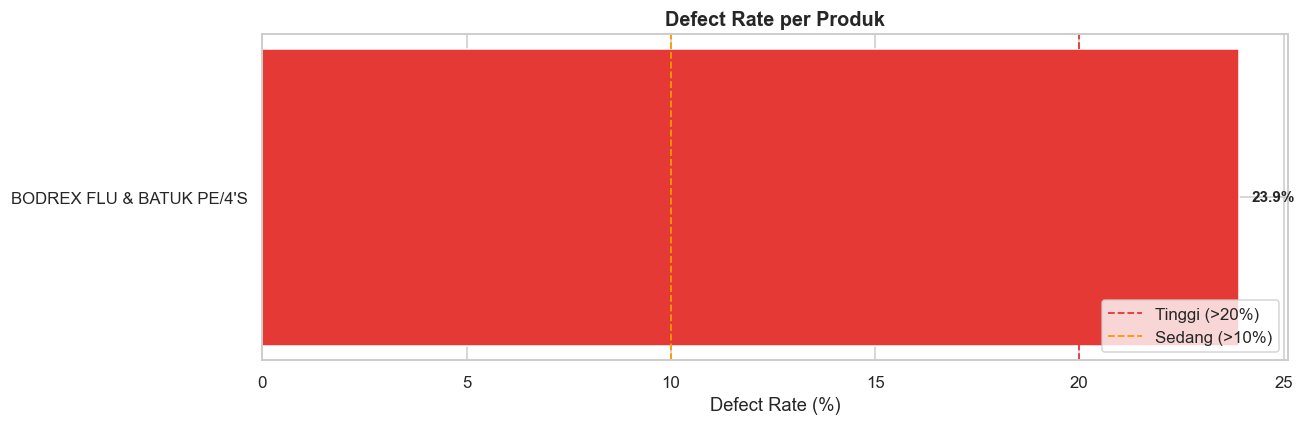

                           Defect  Total  Defect_Rate_%
material_desc                                          
BODREX FLU & BATUK PE/4'S      11     46          23.91


In [9]:
# Defect rate per produk
defect_rate = (
    df.groupby('material_desc')['is_defect']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'Defect', 'count': 'Total'})
)
defect_rate['Defect_Rate_%'] = (defect_rate['Defect'] / defect_rate['Total'] * 100).round(2)
defect_rate = defect_rate.sort_values('Defect_Rate_%', ascending=False)

fig, ax = plt.subplots(figsize=(12, max(4, len(defect_rate) * 0.5 + 1)))
bar_colors = ['#E53935' if r > 20 else '#FF9800' if r > 10 else '#4CAF50'
              for r in defect_rate['Defect_Rate_%']]
bars = ax.barh(defect_rate.index, defect_rate['Defect_Rate_%'],
               color=bar_colors, edgecolor='white', height=0.5)
ax.axvline(20, color='#E53935', linestyle='--', lw=1.2, label='Tinggi (>20%)')
ax.axvline(10, color='#FF9800', linestyle='--', lw=1.2, label='Sedang (>10%)')
ax.set_xlabel('Defect Rate (%)')
ax.set_title('Defect Rate per Produk', fontweight='bold', fontsize=13)
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=10, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("outputs/eda_plot_02.png", dpi=150, bbox_inches="tight")
plt.show()
print(defect_rate[['Defect','Total','Defect_Rate_%']].to_string())

---
## 3. Distribusi Variabel Numerik Kunci

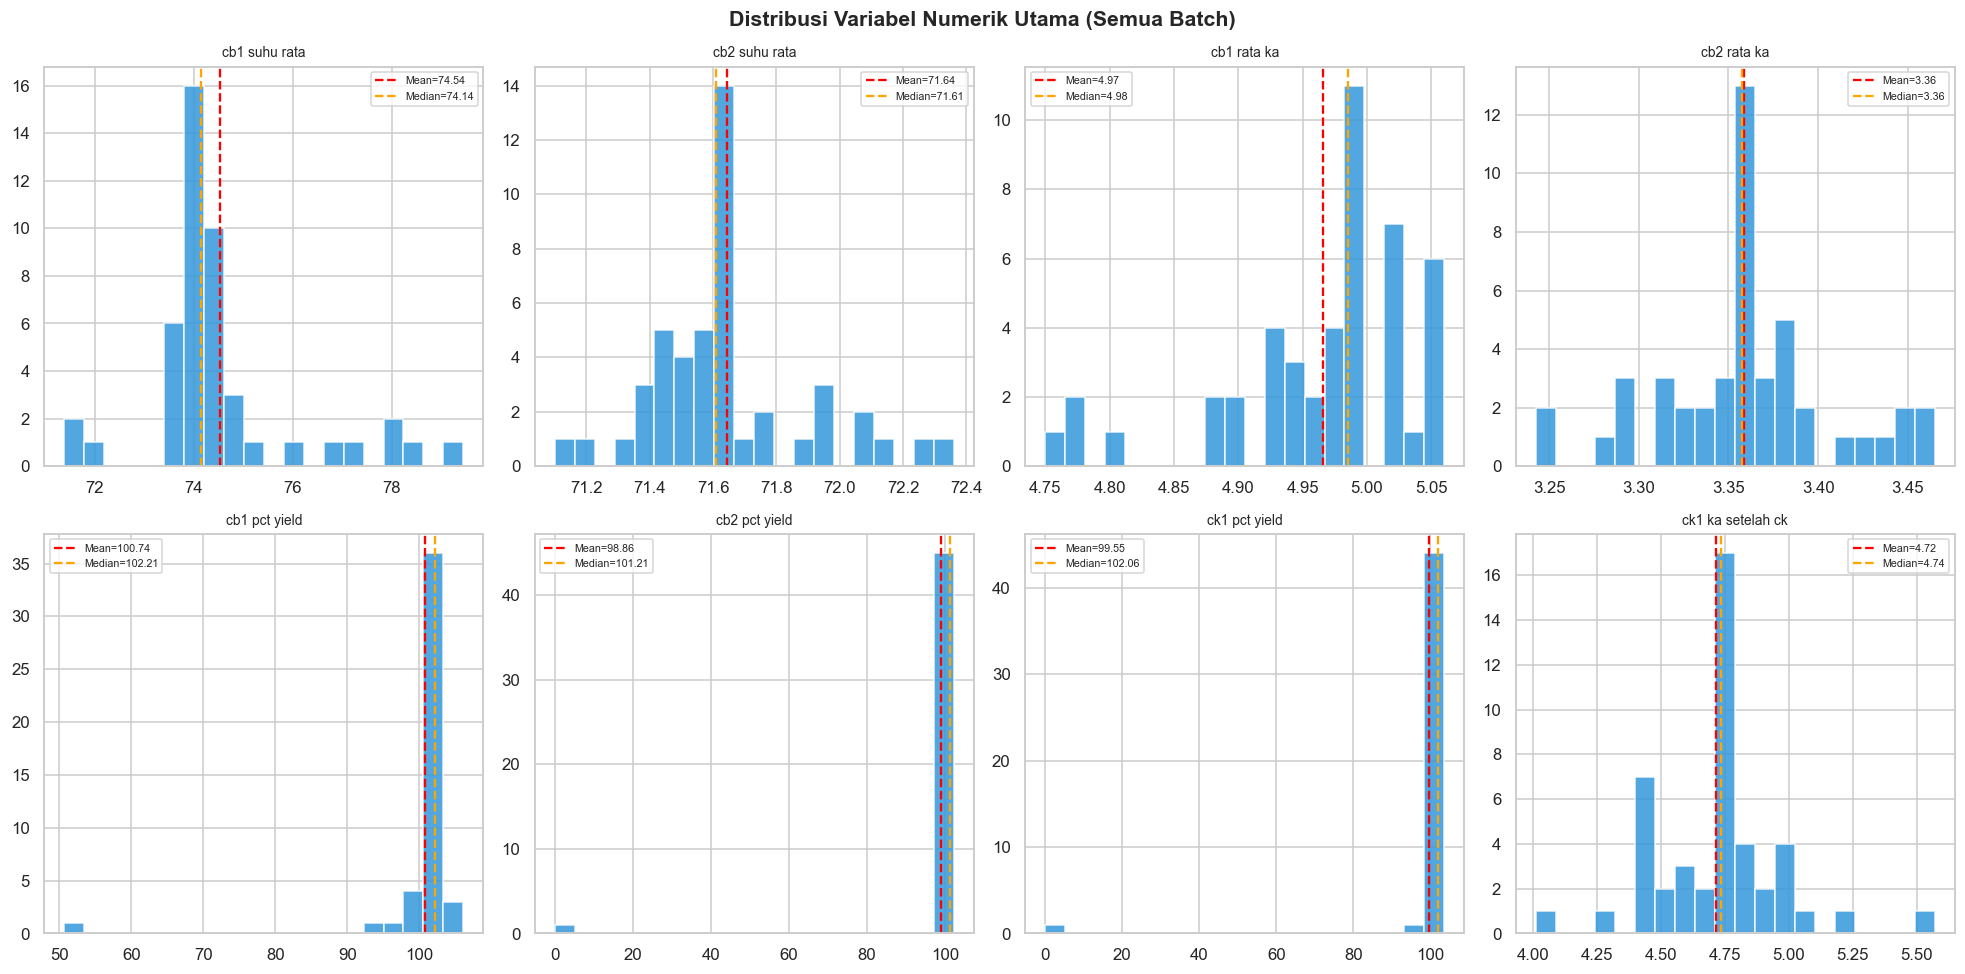

In [10]:
numeric_keys = [
    'cb1_suhu_rata', 'cb2_suhu_rata',
    'cb1_rata_ka',   'cb2_rata_ka',
    'cb1_pct_yield', 'cb2_pct_yield',
    'ck1_pct_yield', 'ck1_ka_setelah_ck',
]
numeric_keys = [c for c in numeric_keys if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
fig.suptitle('Distribusi Variabel Numerik Utama (Semua Batch)',
             fontsize=14, fontweight='bold')

for i, col in enumerate(numeric_keys):
    data_c = df[col].dropna()
    axes[i].hist(data_c, bins=20, color='#3498db', edgecolor='white', alpha=0.85)
    axes[i].axvline(data_c.mean(),   color='red',    linestyle='--', lw=1.5,
                    label=f'Mean={data_c.mean():.2f}')
    axes[i].axvline(data_c.median(), color='orange', linestyle='--', lw=1.5,
                    label=f'Median={data_c.median():.2f}')
    axes[i].set_title(col.replace('_',' '), fontsize=9)
    axes[i].legend(fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("outputs/eda_plot_03.png", dpi=150, bbox_inches="tight")
plt.show()

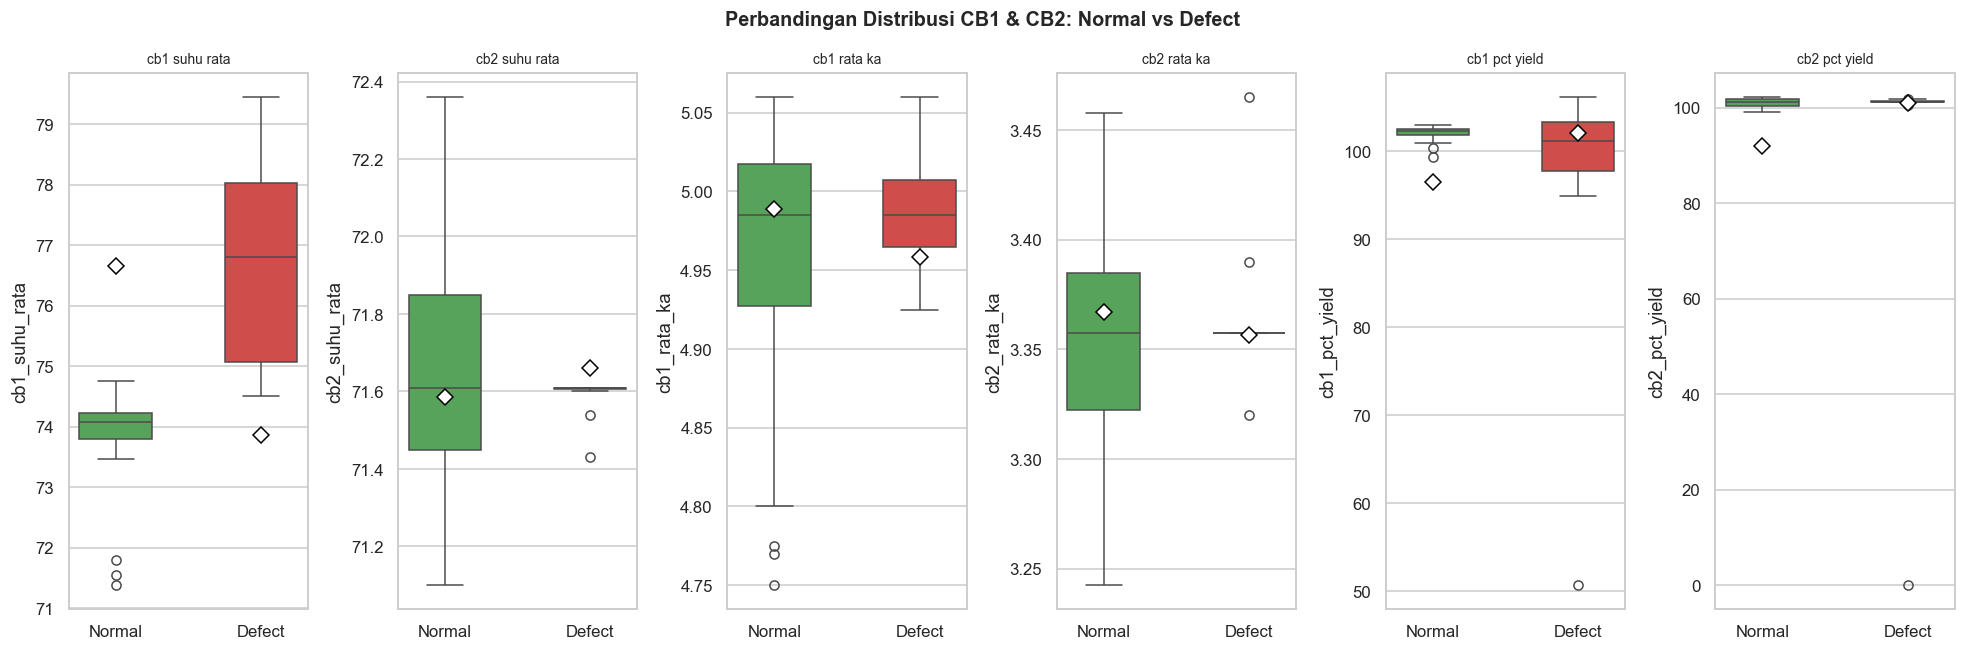

Titik berlian (◆) = rata-rata per kelas


In [11]:
compare_cols = ['cb1_suhu_rata','cb2_suhu_rata',
                'cb1_rata_ka',  'cb2_rata_ka',
                'cb1_pct_yield','cb2_pct_yield']
compare_cols = [c for c in compare_cols if c in df.columns]

df_box = df.copy()
df_box['Kelas'] = df_box['is_defect'].map(LABEL_MAP)

fig, axes = plt.subplots(1, len(compare_cols), figsize=(18, 6))
fig.suptitle('Perbandingan Distribusi CB1 & CB2: Normal vs Defect',
             fontsize=13, fontweight='bold')
for i, col in enumerate(compare_cols):
    sns.boxplot(data=df_box, x='Kelas', y=col,
                palette=[PALETTE[0], PALETTE[1]],
                ax=axes[i], width=0.5, order=['Normal','Defect'])
    means = df_box.groupby('Kelas')[col].mean()
    for j, (kelas, mv) in enumerate(means.items()):
        axes[i].plot(j, mv, 'D', color='white', markersize=7,
                     markeredgecolor='black', zorder=5)
    axes[i].set_title(col.replace('_',' '), fontsize=9)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig("outputs/eda_plot_04.png", dpi=150, bbox_inches="tight")
plt.show()
print('Titik berlian (◆) = rata-rata per kelas')

---
## 4. Analisis Suhu Decoct (Parameter Kritis Granulasi)

Suhu decoct = suhu larutan pengikat saat masuk granulator (DIOSNA).  
Suhu terlalu tinggi (>75°C) menyebabkan granul tidak terbentuk sempurna sehingga termasuk kategori defect.

In [12]:
SUHU_THRESHOLD = 75.0

for lapis, prefix, lots in [
    ('CB1 (Lapis 1)', 'cb1', ['cb1_suhu_lot1_1','cb1_suhu_lot1_2',
                               'cb1_suhu_lot2_1','cb1_suhu_lot2_2','cb1_suhu_rata']),
    ('CB2 (Lapis 2)', 'cb2', ['cb2_suhu_lot1_1','cb2_suhu_lot1_2',
                               'cb2_suhu_lot2_1','cb2_suhu_lot2_2',
                               'cb2_suhu_lot3_1','cb2_suhu_lot3_2',
                               'cb2_suhu_lot4_1','cb2_suhu_lot4_2','cb2_suhu_rata']),
]:
    cols_avail = [c for c in lots if c in df.columns]
    if not cols_avail:
        continue
    print('='*60)
    print(f'  {lapis}')
    print('='*60)
    stats = df.groupby('is_defect')[cols_avail].agg(['mean','std','min','max']).T
    stats.columns = [LABEL_MAP[c] for c in stats.columns]
    print(stats.round(3).to_string())
    print()

    rata_col = f'{prefix}_suhu_rata'
    if rata_col in df.columns:
        n = df[df.is_defect==0][rata_col].mean()
        d = df[df.is_defect==1][rata_col].mean()
        print(f'  Rata-rata suhu NORMAL : {n:.2f} °C')
        print(f'  Rata-rata suhu DEFECT : {d:.2f} °C  (selisih {d-n:+.2f} °C)')
        for label in [0, 1]:
            sub = df[df.is_defect==label][rata_col].dropna()
            pct = (sub > SUHU_THRESHOLD).mean() * 100
            print(f'  Batch {LABEL_MAP[label]:8s} suhu > {SUHU_THRESHOLD}°C: {pct:.1f}% ({(sub > SUHU_THRESHOLD).sum()} dari {len(sub)})')
    print()

  CB1 (Lapis 1)
                      Normal  Defect
cb1_suhu_lot1_1 mean  73.920  76.745
                std    0.848   2.623
                min   71.300  73.600
                max   75.000  80.400
cb1_suhu_lot1_2 mean  73.866  77.836
                std    0.902   1.932
                min   71.200  74.900
                max   74.900  80.900
cb1_suhu_lot2_1 mean  73.817  75.136
                std    0.997   2.650
                min   70.200  71.100
                max   74.900  80.600
cb1_suhu_lot2_2 mean  73.874  76.918
                std    0.779   2.361
                min   71.500  73.900
                max   75.000  80.600
cb1_suhu_rata   mean  73.869  76.658
                std    0.779   1.695
                min   71.380  74.500
                max   74.750  79.450

  Rata-rata suhu NORMAL : 73.87 °C
  Rata-rata suhu DEFECT : 76.66 °C  (selisih +2.79 °C)
  Batch Normal   suhu > 75.0°C: 0.0% (0 dari 35)
  Batch Defect   suhu > 75.0°C: 72.7% (8 dari 11)

  CB2 (Lapis 2)


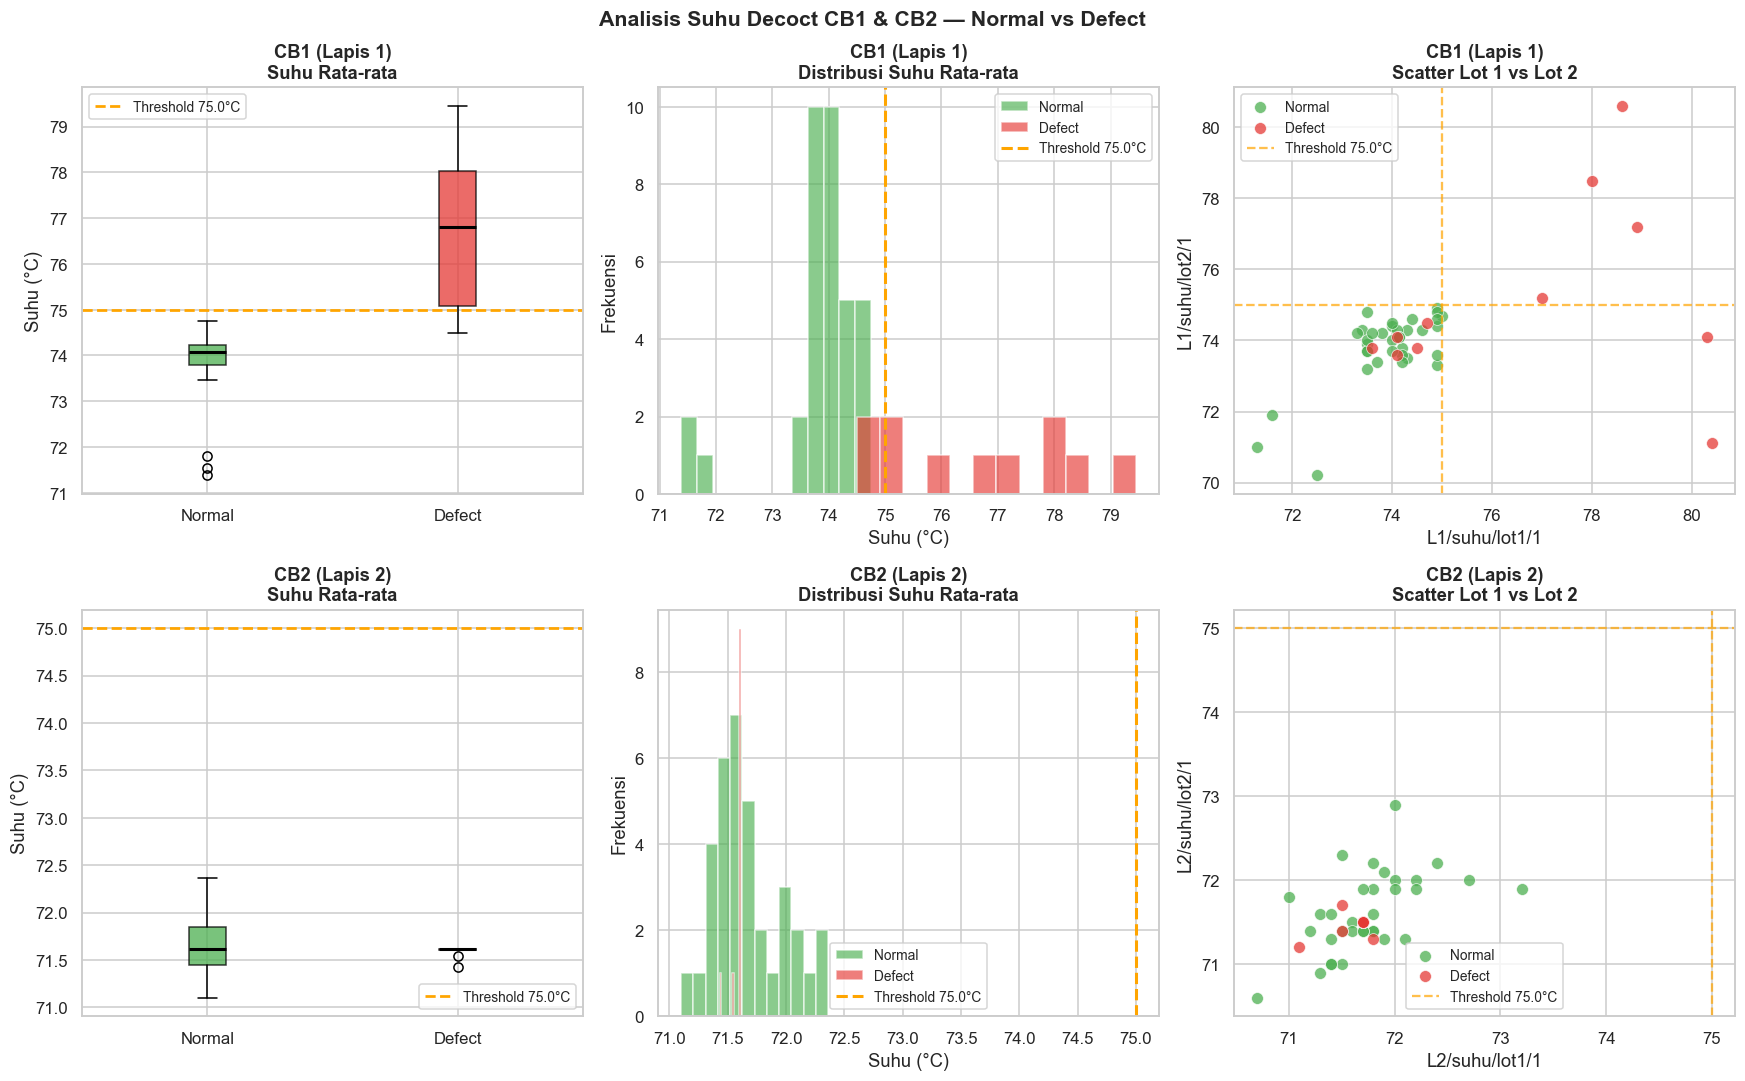

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Analisis Suhu Decoct CB1 & CB2 — Normal vs Defect',
             fontsize=14, fontweight='bold')

for row_idx, (lapis, prefix, suhu_lots) in enumerate([
    ('CB1 (Lapis 1)', 'cb1', ['cb1_suhu_lot1_1','cb1_suhu_lot1_2',
                               'cb1_suhu_lot2_1','cb1_suhu_lot2_2']),
    ('CB2 (Lapis 2)', 'cb2', ['cb2_suhu_lot1_1','cb2_suhu_lot1_2',
                               'cb2_suhu_lot2_1','cb2_suhu_lot2_2']),
]):
    rata_col  = f'{prefix}_suhu_rata'
    lots_avail = [c for c in suhu_lots if c in df.columns]

    # Panel 1: Boxplot rata-rata suhu
    ax = axes[row_idx, 0]
    if rata_col in df.columns:
        data_grp = [df[df.is_defect==0][rata_col].dropna(),
                    df[df.is_defect==1][rata_col].dropna()]
        bp = ax.boxplot(data_grp, patch_artist=True,
                        medianprops=dict(color='black', linewidth=2))
        for patch, color in zip(bp['boxes'], [PALETTE[0], PALETTE[1]]):
            patch.set_facecolor(color); patch.set_alpha(0.75)
        ax.axhline(SUHU_THRESHOLD, color='orange', linestyle='--', lw=1.8,
                   label=f'Threshold {SUHU_THRESHOLD}°C')
        ax.set_xticklabels(['Normal', 'Defect'])
        ax.set_ylabel('Suhu (°C)')
        ax.legend(fontsize=9)
    ax.set_title(f'{lapis}\nSuhu Rata-rata', fontweight='bold')

    # Panel 2: Histogram
    ax = axes[row_idx, 1]
    if rata_col in df.columns:
        for label, color in PALETTE.items():
            sub = df[df.is_defect==label][rata_col].dropna()
            ax.hist(sub, bins=12, alpha=0.65, color=color,
                    label=LABEL_MAP[label], edgecolor='white')
        ax.axvline(SUHU_THRESHOLD, color='orange', linestyle='--', lw=2,
                   label=f'Threshold {SUHU_THRESHOLD}°C')
        ax.set_xlabel('Suhu (°C)'); ax.set_ylabel('Frekuensi')
        ax.legend(fontsize=9)
    ax.set_title(f'{lapis}\nDistribusi Suhu Rata-rata', fontweight='bold')

    # Panel 3: Scatter lot1 vs lot2
    ax = axes[row_idx, 2]
    if len(lots_avail) >= 3:
        x_col, y_col = lots_avail[0], lots_avail[2]
        for label, color in PALETTE.items():
            sub = df[df.is_defect==label]
            ax.scatter(sub[x_col], sub[y_col], color=color, alpha=0.75,
                       s=60, edgecolors='white', linewidth=0.5, label=LABEL_MAP[label])
        ax.axhline(SUHU_THRESHOLD, color='orange', linestyle='--', lw=1.5, alpha=0.7)
        ax.axvline(SUHU_THRESHOLD, color='orange', linestyle='--', lw=1.5, alpha=0.7,
                   label=f'Threshold {SUHU_THRESHOLD}°C')
        ax.set_xlabel(x_col.replace('_','/').replace('cb1','L1').replace('cb2','L2'))
        ax.set_ylabel(y_col.replace('_','/').replace('cb1','L1').replace('cb2','L2'))
        ax.legend(fontsize=9)
    ax.set_title(f'{lapis}\nScatter Lot 1 vs Lot 2', fontweight='bold')

plt.tight_layout()
plt.savefig("outputs/eda_plot_05.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Analisis Kadar Air / KA (Moisture Content)

KA diukur di setiap lot selama granulasi basah, lalu sekali lagi setelah campur kering.  
Rentang normal KA yaitu 3.0% – 5.5%  
KA di luar range ini, atau ada nilai ekstrem (>10%), mengindikasikan defect.

In [14]:
KA_LOW, KA_HIGH = 3.0, 5.5

for lapis, ka_cols, ck_col in [
    ('Lapis 1', ['cb1_ka1','cb1_ka2','cb1_rata_ka'], 'ck1_ka_setelah_ck'),
    ('Lapis 2', ['cb2_ka1','cb2_ka2','cb2_ka3','cb2_ka4','cb2_rata_ka'], 'ck2_ka_setelah_ck'),
]:
    avail = [c for c in ka_cols if c in df.columns]
    ck_avail = ck_col if ck_col in df.columns else None
    if not avail:
        continue
    print('='*60)
    print(f'  {lapis}')
    print('='*60)
    stats_ka = df.groupby('is_defect')[avail].agg(['mean','std','min','max']).T
    stats_ka.columns = [LABEL_MAP[c] for c in stats_ka.columns]
    print(stats_ka.round(4).to_string())
    print()
    rata_col = [c for c in avail if 'rata' in c]
    if rata_col:
        rc = rata_col[0]
        for label in [0, 1]:
            sub = df[df.is_defect==label][rc].dropna()
            out = ((sub < KA_LOW) | (sub > KA_HIGH)).sum()
            print(f'  {LABEL_MAP[label]:8s}: rata KA = {sub.mean():.3f}%  '
                  f'| di luar range: {out}/{len(sub)} ({out/len(sub)*100:.1f}%)')
    if ck_avail:
        print(f'\n  KA setelah Campur Kering ({ck_avail}):')
        ck_stats = df.groupby('is_defect')[ck_avail].agg(['mean','std','min','max'])
        ck_stats.index = [LABEL_MAP[i] for i in ck_stats.index]
        print(ck_stats.round(4).to_string())
    print()

  Lapis 1
                  Normal  Defect
cb1_ka1     mean  4.9363  5.0209
            std   0.1116  0.0459
            min   4.7200  4.9400
            max   5.1000  5.0800
cb1_ka2     mean  4.9803  4.9609
            std   0.1066  0.0834
            min   4.7100  4.8100
            max   5.1000  5.0800
cb1_rata_ka mean  4.9581  4.9891
            std   0.0833  0.0424
            min   4.7500  4.9250
            max   5.0600  5.0600

  Normal  : rata KA = 4.958%  | di luar range: 0/35 (0.0%)
  Defect  : rata KA = 4.989%  | di luar range: 0/11 (0.0%)

  KA setelah Campur Kering (ck1_ka_setelah_ck):
          mean     std   min   max
Normal  4.6864  0.2515  4.01  5.18
Defect  4.8095  0.2574  4.61  5.57

  Lapis 2
                  Normal  Defect
cb2_ka1     mean  3.3726  3.3800
            std   0.1095  0.0714
            min   3.1200  3.1700
            max   3.5000  3.4400
cb2_ka2     mean  3.3584  3.4041
            std   0.1012  0.0569
            min   3.1200  3.2700
            m

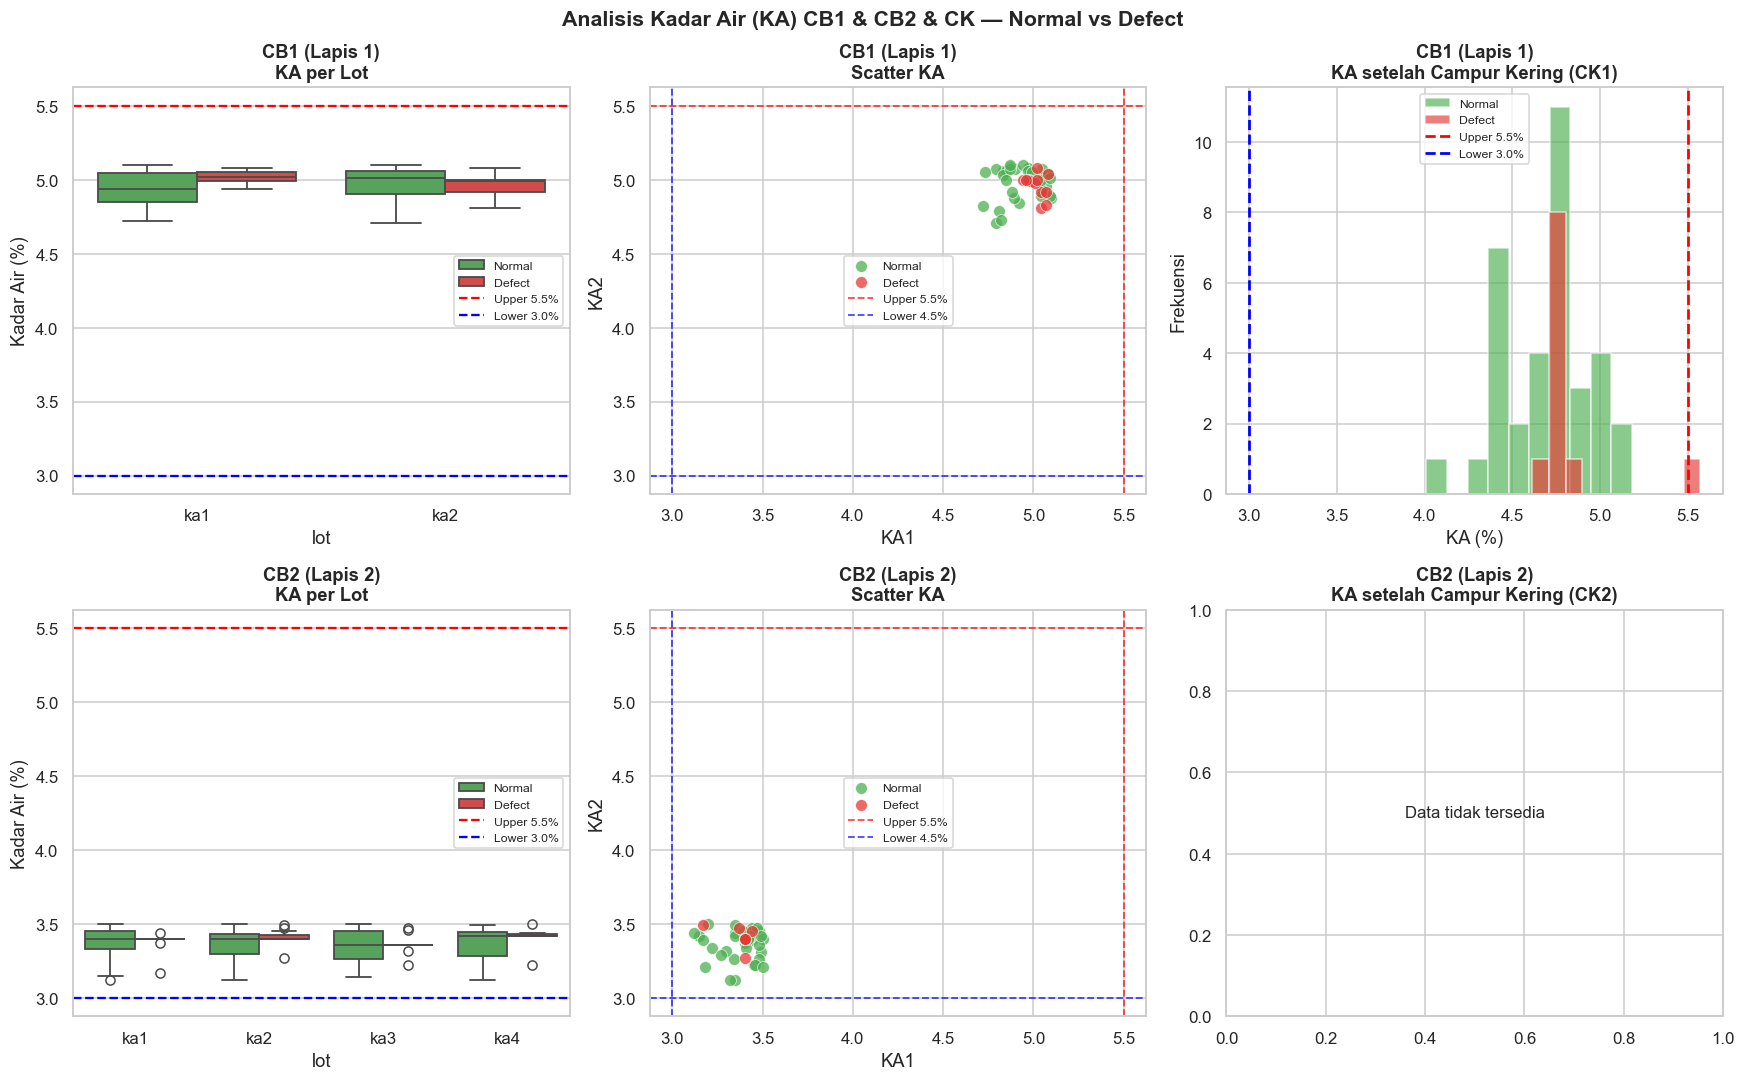

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Analisis Kadar Air (KA) CB1 & CB2 & CK — Normal vs Defect',
             fontsize=14, fontweight='bold')

configs = [
    ('CB1 (Lapis 1)',  ['cb1_ka1','cb1_ka2'],        'cb1_rata_ka',      'ck1_ka_setelah_ck', 0),
    ('CB2 (Lapis 2)',  ['cb2_ka1','cb2_ka2','cb2_ka3','cb2_ka4'], 'cb2_rata_ka', 'ck2_ka_setelah_ck', 1),
]

for row_idx, (lapis, ka_lot_cols, rata_col, ck_col, ri) in enumerate(configs):
    avail = [c for c in ka_lot_cols if c in df.columns]

    # Panel 1: Boxplot KA per lot
    ax = axes[row_idx, 0]
    if avail:
        df_ka = df[avail + ['is_defect']].melt(id_vars='is_defect',
                                                var_name='lot', value_name='KA')
        df_ka['Label'] = df_ka['is_defect'].map(LABEL_MAP)
        df_ka['lot'] = df_ka['lot'].str.replace(r'cb[12]_','', regex=True)
        sns.boxplot(data=df_ka, x='lot', y='KA', hue='Label',
                    palette={LABEL_MAP[k]: v for k, v in PALETTE.items()}, ax=ax, linewidth=1.2)
        ax.axhline(KA_HIGH, color='red',  linestyle='--', lw=1.5, label=f'Upper {KA_HIGH}%')
        ax.axhline(KA_LOW,  color='blue', linestyle='--', lw=1.5, label=f'Lower {KA_LOW}%')
        ax.set_ylabel('Kadar Air (%)')
        ax.legend(fontsize=8)
    ax.set_title(f'{lapis}\nKA per Lot', fontweight='bold')

    # Panel 2: Scatter KA lot1 vs KA lot2
    ax = axes[row_idx, 1]
    x_ka = avail[0] if avail else None
    y_ka = avail[1] if len(avail) > 1 else None
    if x_ka and y_ka:
        for label, color in PALETTE.items():
            sub = df[df.is_defect==label]
            ax.scatter(sub[x_ka], sub[y_ka], color=color, alpha=0.75,
                       s=60, edgecolors='white', lw=0.5, label=LABEL_MAP[label])
        ax.axhline(KA_HIGH, color='red',  linestyle='--', lw=1.2, alpha=0.7)
        ax.axhline(KA_LOW,  color='blue', linestyle='--', lw=1.2, alpha=0.7)
        ax.axvline(KA_HIGH, color='red',  linestyle='--', lw=1.2, alpha=0.7, label='Upper 5.5%')
        ax.axvline(KA_LOW,  color='blue', linestyle='--', lw=1.2, alpha=0.7, label='Lower 4.5%')
        ax.set_xlabel(x_ka.split('_')[-1].upper())
        ax.set_ylabel(y_ka.split('_')[-1].upper())
        ax.legend(fontsize=8)
    ax.set_title(f'{lapis}\nScatter KA', fontweight='bold')

    # Panel 3: Histogram KA setelah CK
    ax = axes[row_idx, 2]
    ck_avail = ck_col if ck_col in df.columns else None
    if ck_avail:
        for label, color in PALETTE.items():
            sub = df[df.is_defect==label][ck_avail].dropna()
            ax.hist(sub, bins=10, alpha=0.65, color=color,
                    label=LABEL_MAP[label], edgecolor='white')
        ax.axvline(KA_HIGH, color='red',  linestyle='--', lw=1.8, label=f'Upper {KA_HIGH}%')
        ax.axvline(KA_LOW,  color='blue', linestyle='--', lw=1.8, label=f'Lower {KA_LOW}%')
        ax.set_xlabel('KA (%)')
        ax.set_ylabel('Frekuensi')
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, 'Data tidak tersedia', ha='center', va='center',
                transform=ax.transAxes)
    ck_label = ck_col.replace('_ka_setelah_ck','').upper()
    ax.set_title(f'{lapis}\nKA setelah Campur Kering ({ck_label})', fontweight='bold')

plt.tight_layout()
plt.savefig("outputs/eda_plot_06.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# Deteksi nilai KA ekstrem di semua lapis
print('Deteksi nilai KA ekstrem (>10%)')
print()

# Kolom KA aktual saja (bukan flag _ekstrem, bukan _raw, bukan outlier marker)
ka_all_cols = [c for c in df.columns if '_ka' in c
               and 'rata' not in c
               and 'outlier' not in c
               and 'setelah' not in c
               and 'ekstrem' not in c   # exclude flag kolom baru dari preprocessing
               and '_raw' not in c]     # exclude raw backup kolom

found = False
for col in ka_all_cols:
    extreme = df[df[col] > 10][['material_desc','batch_ke','is_defect', col]]
    if len(extreme):
        print(f'  {col}: {len(extreme)} nilai ekstrem')
        print(extreme.to_string())
        print()
        found = True

# Jika preprocessing sudah diperbarui: tampilkan nilai _raw (nilai asli sebelum di-clip)
raw_ka_cols = [c for c in df.columns if c.endswith('_raw') and '_ka' in c]
if raw_ka_cols:
    print('\nNilai KA asli (sebelum di-clip) dari kolom _raw:')
    for col in raw_ka_cols:
        extreme_raw = df[df[col] > 10][['material_desc','batch_ke','is_defect', col]]
        if len(extreme_raw):
            print(f'  {col}: {len(extreme_raw)} nilai ekstrem (NILAI ASLI)')
            print(extreme_raw.to_string())
            print()
            found = True

if not found:
    print('  Tidak ada nilai KA ekstrem (>10%).')
    print('  Catatan: jika preprocessing sudah diperbarui, nilai asli ada di kolom _raw.')

# Jika ada fitur ka_ekstrem_count (dari preprocessing baru), tampilkan distribusinya
if 'ka_ekstrem_count' in df.columns:
    print('\nDistribusi ka_ekstrem_count (jumlah KA abnormal per batch):')
    print(df.groupby('is_defect')['ka_ekstrem_count'].value_counts().sort_index().rename(index=LABEL_MAP))

print('\n→ Nilai KA ekstrem adalah sinyal kuat batch rework/defect.')

Deteksi nilai KA ekstrem (>10%)


Nilai KA asli (sebelum di-clip) dari kolom _raw:
  cb1_ka2_raw: 1 nilai ekstrem (NILAI ASLI)
               material_desc  batch_ke  is_defect  cb1_ka2_raw
3  BODREX FLU & BATUK PE/4'S       5.5          1        50.01


Distribusi ka_ekstrem_count (jumlah KA abnormal per batch):
is_defect  ka_ekstrem_count
Normal     Normal              35
Defect     Normal              10
           Defect               1
Name: count, dtype: int64

→ Nilai KA ekstrem adalah sinyal kuat batch rework/defect.


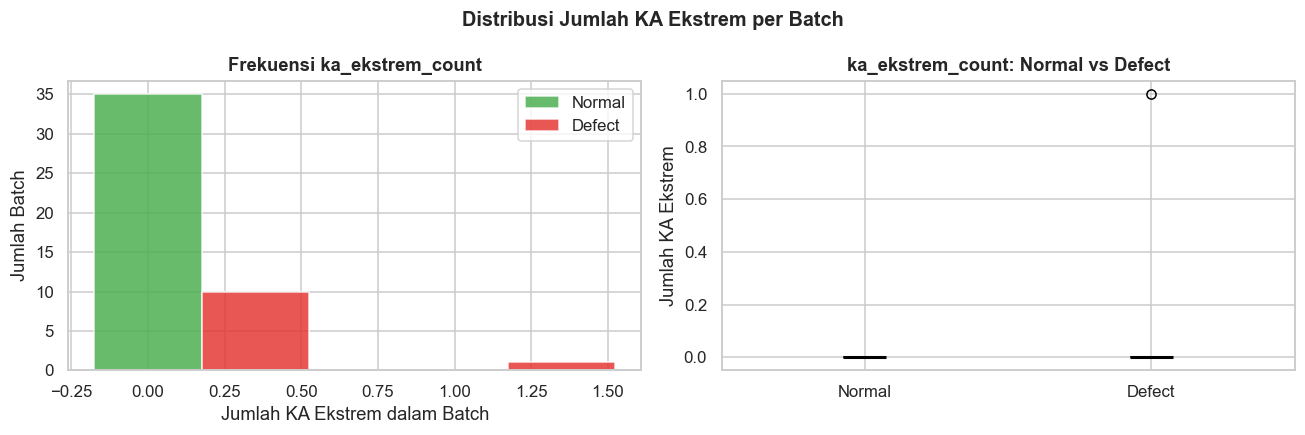

ka_ekstrem_count per label:
           count   mean    std  min  25%  50%  75%  max
is_defect                                              
Normal      35.0  0.000  0.000  0.0  0.0  0.0  0.0  0.0
Defect      11.0  0.091  0.302  0.0  0.0  0.0  0.0  1.0

Korelasi ka_ekstrem_count vs is_defect: +0.2659
→ Semakin tinggi nilai ini, semakin besar kemungkinan batch defect.


In [17]:
# Visualisasi ka_ekstrem_count
if 'ka_ekstrem_count' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Distribusi Jumlah KA Ekstrem per Batch', fontweight='bold', fontsize=13)

    # Bar chart distribusi
    for label in [0, 1]:
        sub = df[df.is_defect == label]['ka_ekstrem_count']
        vc = sub.value_counts().sort_index()
        axes[0].bar([x + label*0.35 for x in vc.index], vc.values,
                    width=0.35, color=PALETTE[label], label=LABEL_MAP[label],
                    edgecolor='white', alpha=0.85)
    axes[0].set_xlabel('Jumlah KA Ekstrem dalam Batch')
    axes[0].set_ylabel('Jumlah Batch')
    axes[0].set_title('Frekuensi ka_ekstrem_count', fontweight='bold')
    axes[0].legend()

    # Boxplot per label
    data_grp = [df[df.is_defect==0]['ka_ekstrem_count'],
                df[df.is_defect==1]['ka_ekstrem_count']]
    bp = axes[1].boxplot(data_grp, patch_artist=True,
                          medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], [PALETTE[0], PALETTE[1]]):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    axes[1].set_xticks([1, 2]); axes[1].set_xticklabels(['Normal', 'Defect'])
    axes[1].set_ylabel('Jumlah KA Ekstrem')
    axes[1].set_title('ka_ekstrem_count: Normal vs Defect', fontweight='bold')

    plt.tight_layout()
    plt.savefig("outputs/eda_plot_07.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Statistik
    print('ka_ekstrem_count per label:')
    print(df.groupby('is_defect')['ka_ekstrem_count'].describe().rename(index=LABEL_MAP).round(3))
    print()
    corr_ka_ext = df['ka_ekstrem_count'].corr(df['is_defect'])
    print(f'Korelasi ka_ekstrem_count vs is_defect: {corr_ka_ext:+.4f}')
    print('→ Semakin tinggi nilai ini, semakin besar kemungkinan batch defect.')
else:
    print('Kolom ka_ekstrem_count belum ada.')
    print('Jalankan ulang 01_preprocessing.ipynb (versi terbaru) untuk menghasilkan fitur ini.')

---
## 6. Analisis % Yield Granulasi

**% Yield** = (Berat Granul Aktual / Teoritis) × 100%  

Spesifikasi standar berdasarkan domain proses:

| Tahap | Batas Bawah | Batas Atas |
|---|---|---|
| CB1 (Granulasi Basah L1) | 99.0% | 103.1% |
| CK1 (Campur Kering L1)  | 99.1% | 102.9% |
| CB2 (Granulasi Basah L2) | 99.1% | 102.3% |

Nilai di luar range bearti terjadi kehilangan atau penambahan massa tidak wajar yang mengindikasikan defect.

In [18]:
YIELD_SPECS = {
    'cb1_pct_yield': (99.0, 103.1, 'CB1 Granulasi Basah L1'),
    'ck1_pct_yield': (99.1, 102.9, 'CK1 Campur Kering L1'),
    'cb2_pct_yield': (99.1, 102.3, 'CB2 Granulasi Basah L2'),
    'ck2_pct_yield': (99.1, 102.9, 'CK2 Campur Kering L2'),
}

for col, (lo, hi, label) in YIELD_SPECS.items():
    if col not in df.columns:
        continue
    print('='*55)
    print(f'  {label}  [{col}]')
    print(f'  Spesifikasi: {lo}% – {hi}%')
    print('='*55)
    stats = df.groupby('is_defect')[col].agg(['mean','std','min','max'])
    stats.index = [LABEL_MAP[i] for i in stats.index]
    print(stats.round(4).to_string())
    print()
    for lbl in [0, 1]:
        sub = df[df.is_defect==lbl][col].dropna()
        out = ((sub < lo) | (sub > hi)).sum()
        print(f'  {LABEL_MAP[lbl]:8s}: {out}/{len(sub)} batch di luar spec ({out/len(sub)*100:.1f}%)')
    print()

  CB1 Granulasi Basah L1  [cb1_pct_yield]
  Spesifikasi: 99.0% – 103.1%
            mean      std      min       max
Normal  102.0783   0.7535  99.3244  102.9398
Defect   96.5023  15.5833  50.6789  106.1204

  Normal  : 0/35 batch di luar spec (0.0%)
  Defect  : 6/11 batch di luar spec (54.5%)

  CK1 Campur Kering L1  [ck1_pct_yield]
  Spesifikasi: 99.1% – 102.9%
            mean      std       min       max
Normal  102.0009   0.5806  100.2857  102.6349
Defect   91.7489  30.5121    0.0000  103.5873

  Normal  : 0/35 batch di luar spec (0.0%)
  Defect  : 3/11 batch di luar spec (27.3%)

  CB2 Granulasi Basah L2  [cb2_pct_yield]
  Spesifikasi: 99.1% – 102.3%
            mean      std      min       max
Normal  100.9820   0.9180  99.2136  102.2652
Defect   92.1062  30.5505   0.0000  101.8776

  Normal  : 0/35 batch di luar spec (0.0%)
  Defect  : 1/11 batch di luar spec (9.1%)



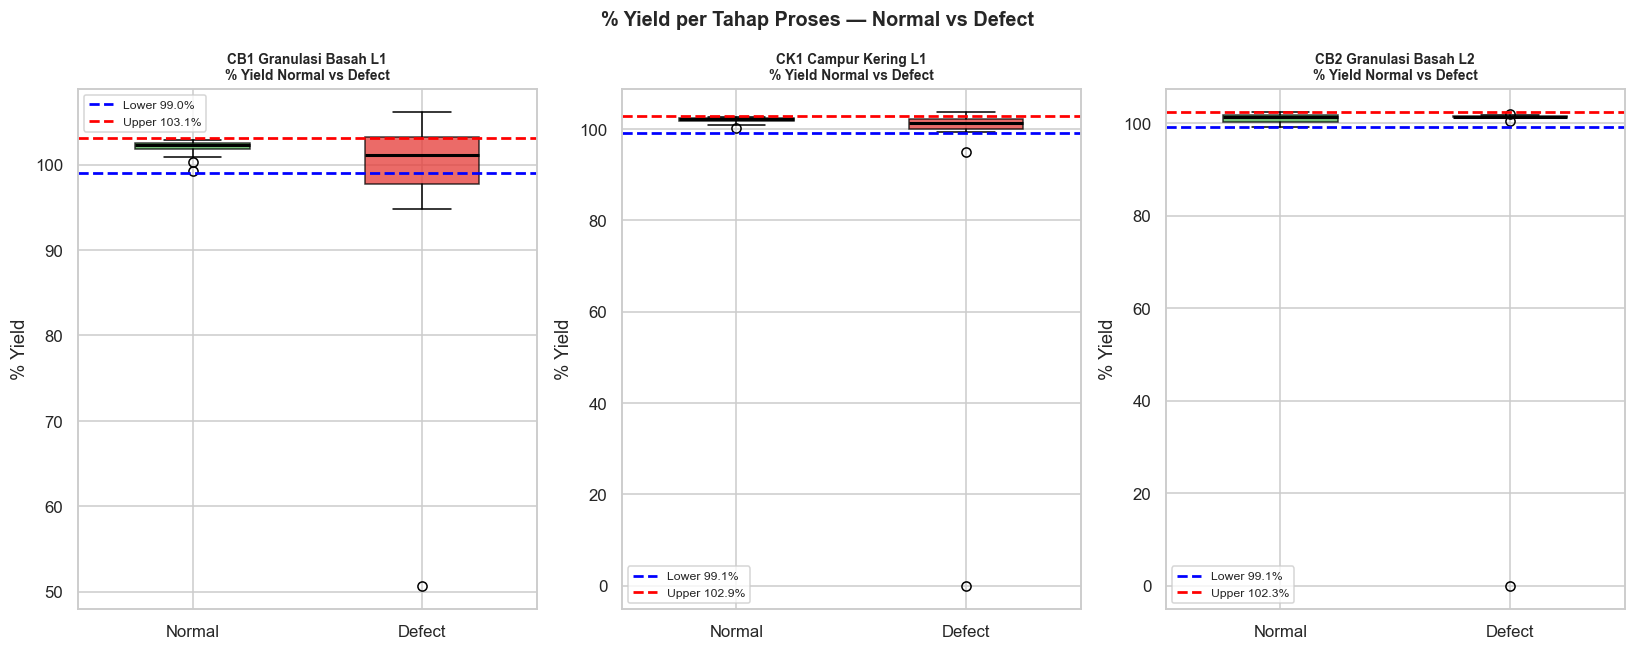

In [19]:
# Boxplot yield semua tahap
yield_cols_avail = [c for c in ['cb1_pct_yield','ck1_pct_yield',
                                  'cb2_pct_yield','ck2_pct_yield'] if c in df.columns]

fig, axes = plt.subplots(1, len(yield_cols_avail), figsize=(5*len(yield_cols_avail), 6))
if len(yield_cols_avail) == 1:
    axes = [axes]
fig.suptitle('% Yield per Tahap Proses — Normal vs Defect', fontsize=13, fontweight='bold')

for ax, col in zip(axes, yield_cols_avail):
    lo, hi, lbl = YIELD_SPECS.get(col, (99.0, 103.1, col))
    data_grp = [df[df.is_defect==0][col].dropna(), df[df.is_defect==1][col].dropna()]
    bp = ax.boxplot(data_grp, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], [PALETTE[0], PALETTE[1]]):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.axhline(lo, color='blue', linestyle='--', lw=1.8, label=f'Lower {lo}%')
    ax.axhline(hi, color='red',  linestyle='--', lw=1.8, label=f'Upper {hi}%')
    ax.set_xticks([1, 2]); ax.set_xticklabels(['Normal', 'Defect'])
    ax.set_ylabel('% Yield')
    ax.set_title(f'{lbl}\n% Yield Normal vs Defect', fontweight='bold', fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("outputs/eda_plot_08.png", dpi=150, bbox_inches="tight")
plt.show()

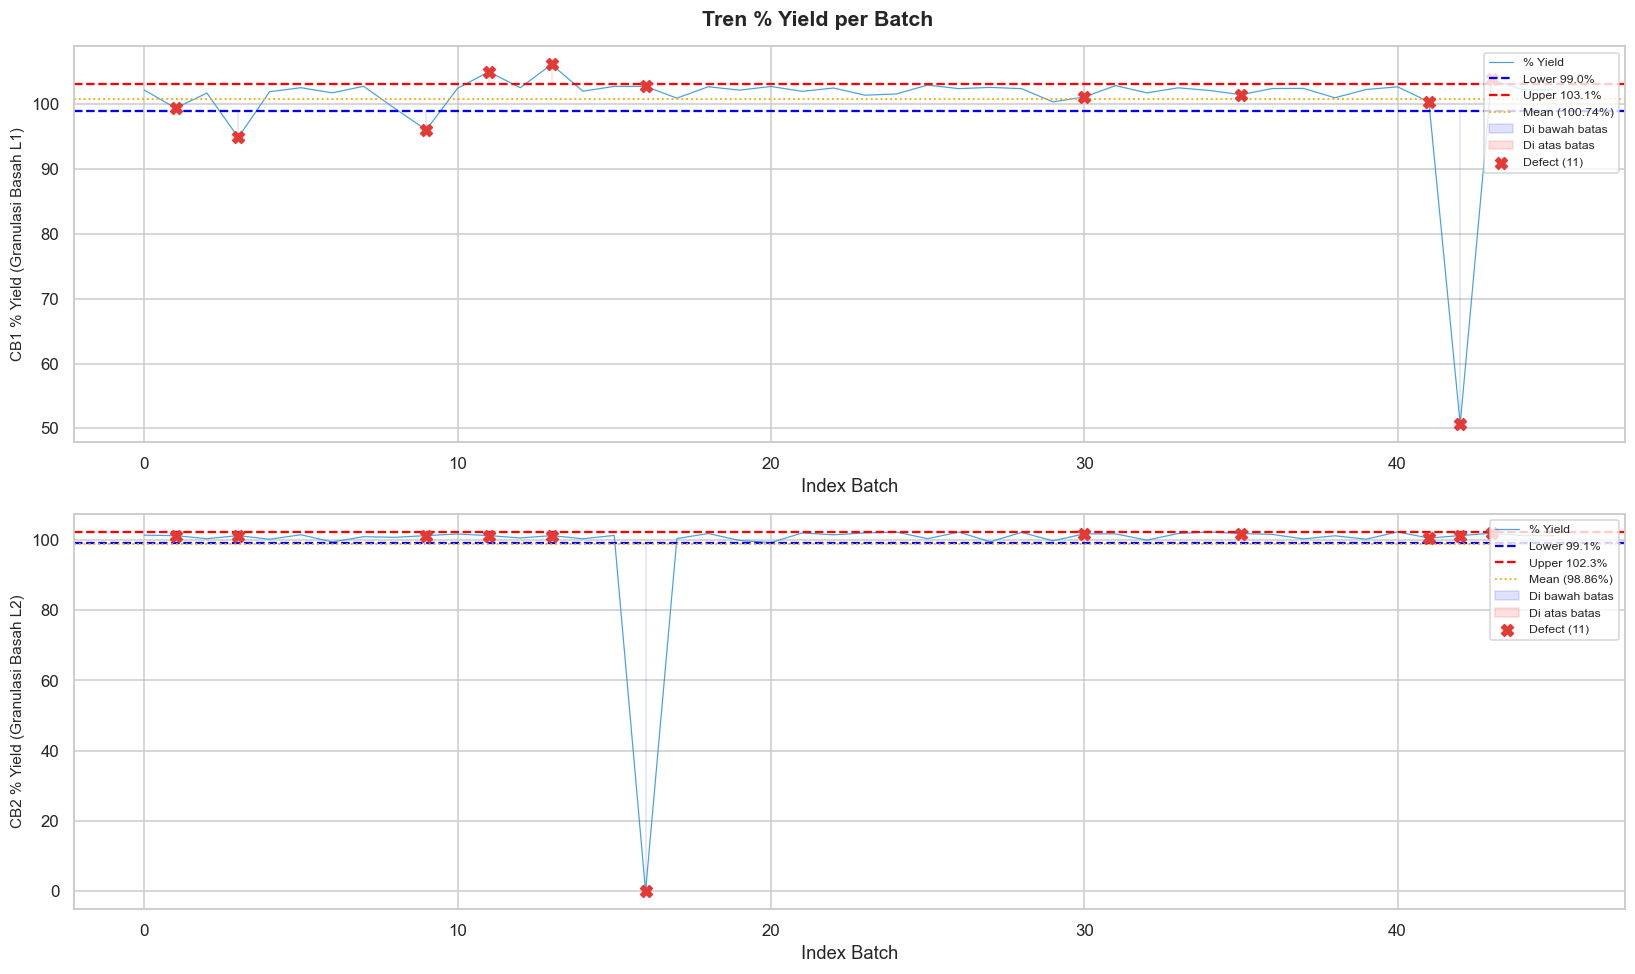

In [20]:
# Trend % Yield per index batch (CB1 & CB2)
fig, axes = plt.subplots(2, 1, figsize=(15, 9))
fig.suptitle('Tren % Yield per Batch', fontsize=14, fontweight='bold')

for ax, col, title, (lo, hi, _) in zip(
    axes,
    ['cb1_pct_yield', 'cb2_pct_yield'],
    ['CB1 % Yield (Granulasi Basah L1)', 'CB2 % Yield (Granulasi Basah L2)'],
    [YIELD_SPECS['cb1_pct_yield'], YIELD_SPECS.get('cb2_pct_yield', (99.1, 102.3, ''))],
):
    if col not in df.columns:
        continue
    data_s = df[col].reset_index(drop=True)
    is_def = df['is_defect'].reset_index(drop=True)
    ax.plot(data_s.index, data_s.values, color='#3498db', lw=0.8, alpha=0.9, label='% Yield')
    ax.axhline(lo, color='blue', linestyle='--', lw=1.5, label=f'Lower {lo}%')
    ax.axhline(hi, color='red',  linestyle='--', lw=1.5, label=f'Upper {hi}%')
    ax.axhline(data_s.mean(), color='orange', linestyle=':', lw=1.2,
               label=f'Mean ({data_s.mean():.2f}%)')
    ax.fill_between(data_s.index, data_s.values, lo,
                    where=(data_s.values < lo),
                    color='blue', alpha=0.12, label='Di bawah batas')
    ax.fill_between(data_s.index, data_s.values, hi,
                    where=(data_s.values > hi),
                    color='red', alpha=0.12, label='Di atas batas')
    # Tandai batch defect
    def_idx = data_s[is_def == 1].index
    ax.scatter(def_idx, data_s[def_idx], color=PALETTE[1], s=60, zorder=5,
               marker='X', label=f'Defect ({len(def_idx)})')
    ax.set_ylabel(title, fontsize=10)
    ax.set_xlabel('Index Batch')
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig("outputs/eda_plot_09.png", dpi=150, bbox_inches="tight")
plt.show()

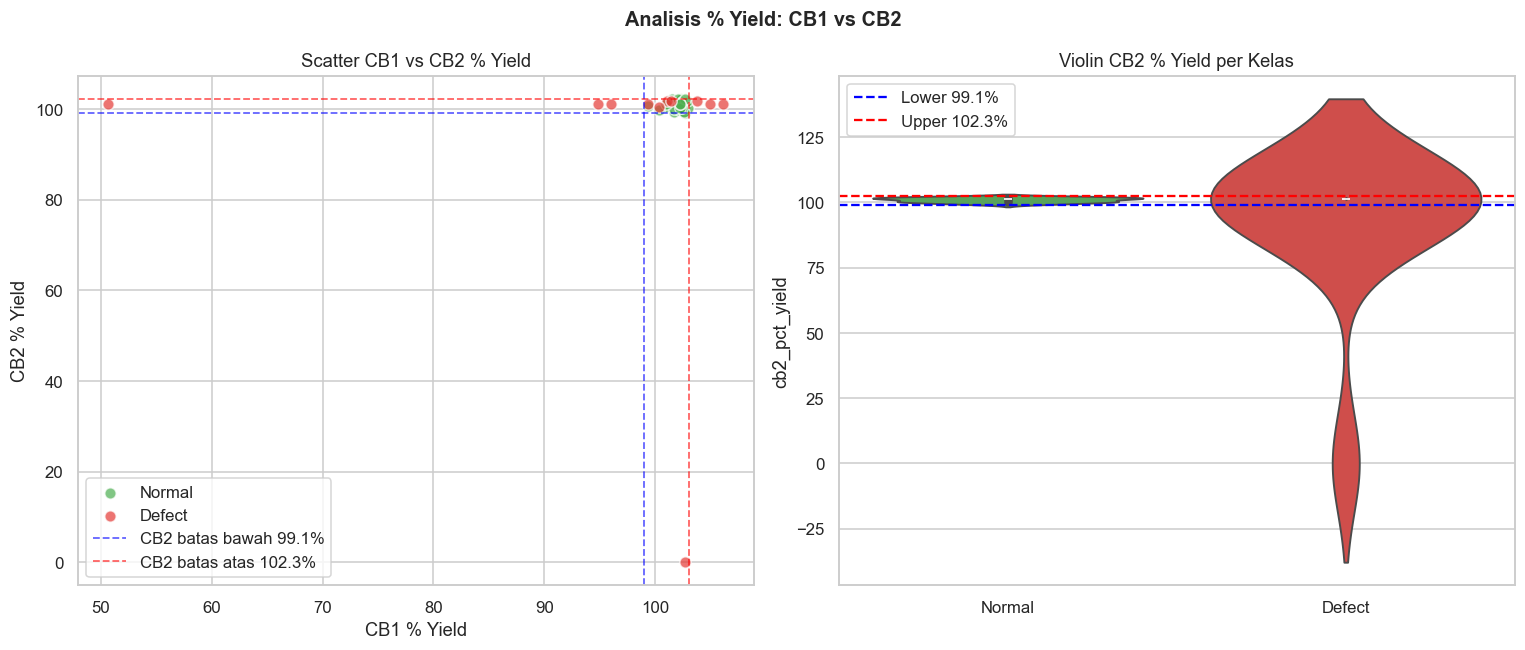

In [21]:
# Scatter CB1 vs CB2 yield
scatter_df = df[['cb1_pct_yield','cb2_pct_yield','is_defect']].dropna().copy()
scatter_df['Kelas'] = scatter_df['is_defect'].map(LABEL_MAP)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Analisis % Yield: CB1 vs CB2', fontsize=13, fontweight='bold')

for kelas, color in [('Normal', PALETTE[0]), ('Defect', PALETTE[1])]:
    msk = scatter_df['Kelas'] == kelas
    axes[0].scatter(scatter_df.loc[msk, 'cb1_pct_yield'],
                    scatter_df.loc[msk, 'cb2_pct_yield'],
                    label=kelas, color=color, alpha=0.7, s=55, edgecolors='white')
axes[0].axvline(99.0, color='blue', linestyle='--', lw=1.2, alpha=0.6)
axes[0].axhline(99.1, color='blue', linestyle='--', lw=1.2, alpha=0.6, label='CB2 batas bawah 99.1%')
axes[0].axvline(103.1, color='red', linestyle='--', lw=1.2, alpha=0.6)
axes[0].axhline(102.3, color='red', linestyle='--', lw=1.2, alpha=0.6, label='CB2 batas atas 102.3%')
axes[0].set_xlabel('CB1 % Yield'); axes[0].set_ylabel('CB2 % Yield')
axes[0].set_title('Scatter CB1 vs CB2 % Yield'); axes[0].legend()

# Violin CB2
df_vln = df[['cb2_pct_yield','is_defect']].dropna().copy()
df_vln['Kelas'] = df_vln['is_defect'].map(LABEL_MAP)
sns.violinplot(data=df_vln, x='Kelas', y='cb2_pct_yield',
               palette=[PALETTE[0], PALETTE[1]], ax=axes[1],
               order=['Normal','Defect'], inner='box')
axes[1].axhline(99.1, color='blue', linestyle='--', lw=1.5, label='Lower 99.1%')
axes[1].axhline(102.3, color='red', linestyle='--', lw=1.5, label='Upper 102.3%')
axes[1].set_title('Violin CB2 % Yield per Kelas')
axes[1].set_xlabel(''); axes[1].legend()

plt.tight_layout()
plt.savefig("outputs/eda_plot_10.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Analisis Parameter Mesin: Mixer, Chopper, Inlet/Outlet

Kecepatan mixer & chopper (rpm) serta suhu inlet/outlet FBD tidak terlalu mempengaruhi  
homogenitas granul dan kualitas pengeringan. Hanya suhu decoct, kadar air, dan % yield yang sangat mempengaruhi kualitas granul tetapi berikut tetap disediakan visualisasinya.

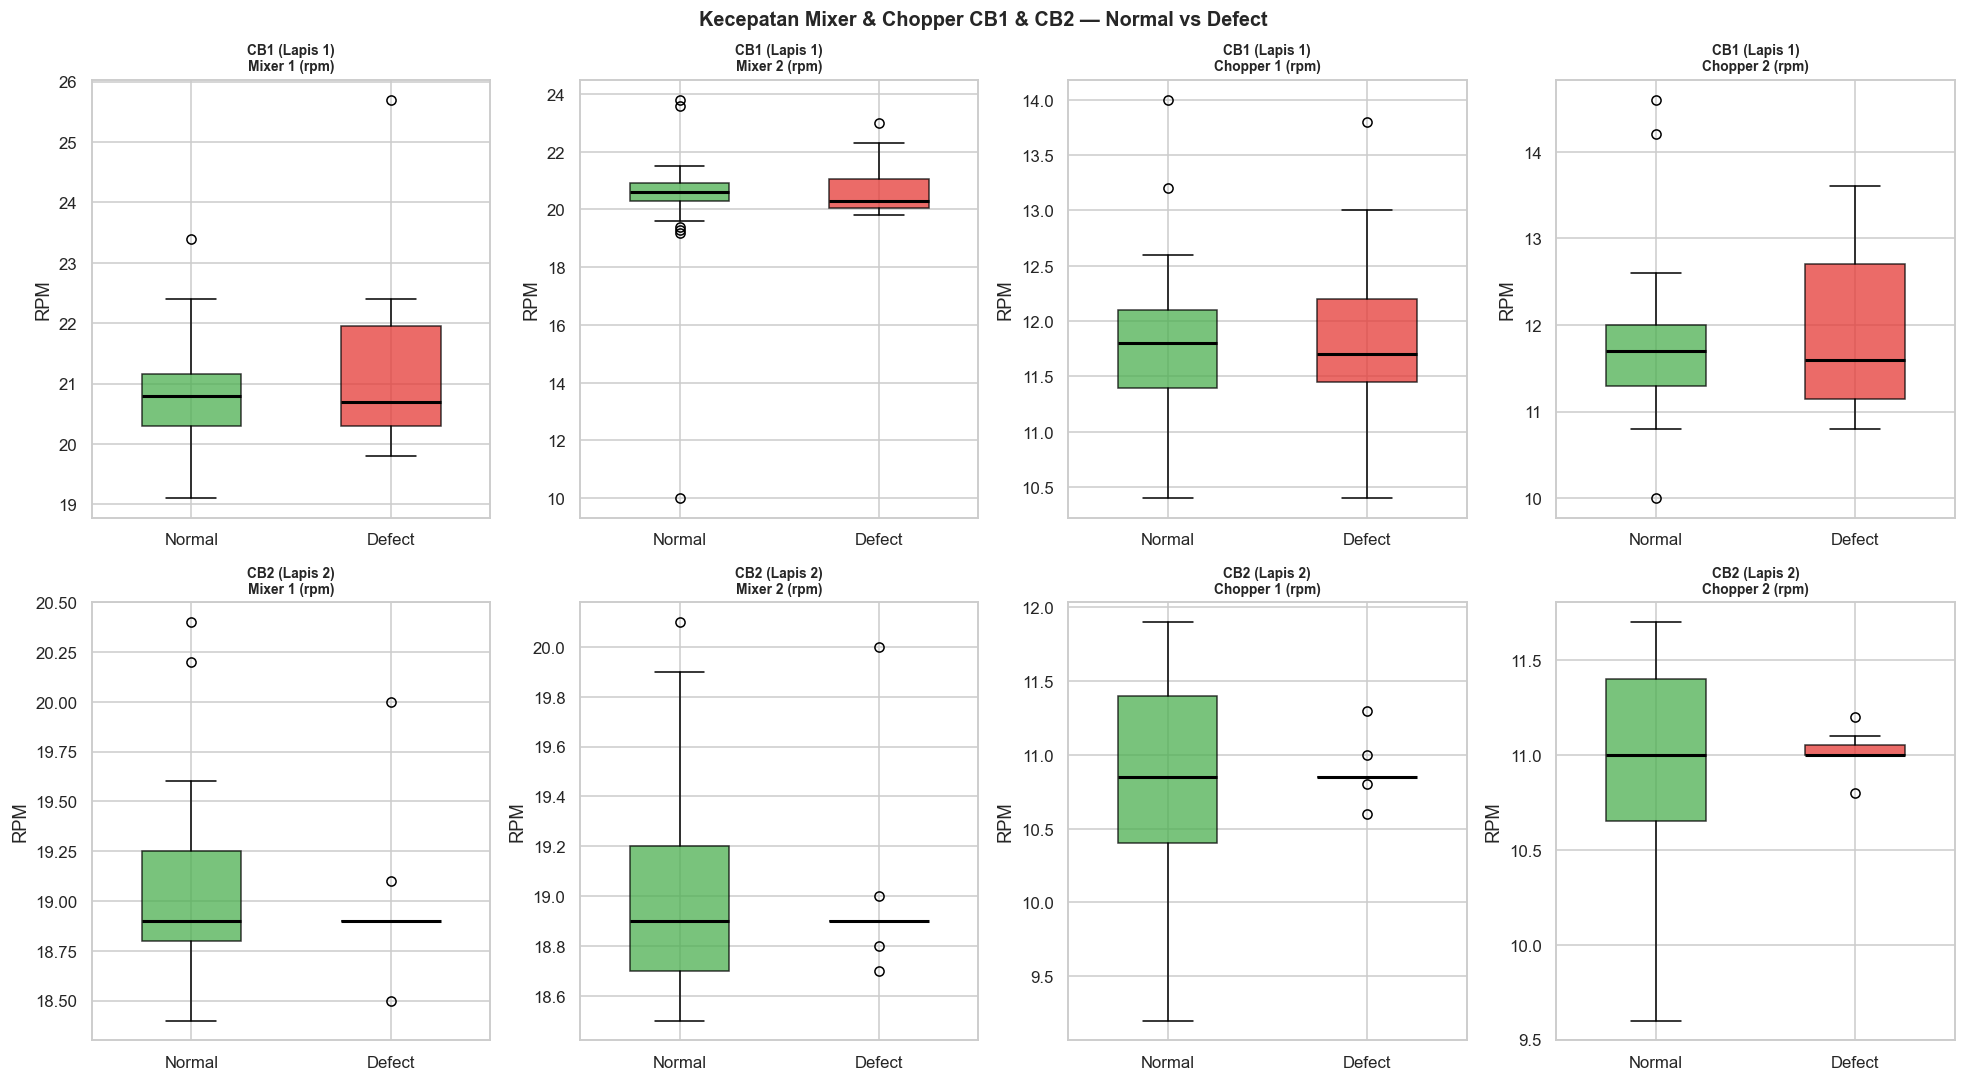

In [22]:
# Mixer & Chopper
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Kecepatan Mixer & Chopper CB1 & CB2 — Normal vs Defect',
             fontsize=13, fontweight='bold')

row_configs = [
    ('CB1 (Lapis 1)', ['cb1_mixer1','cb1_mixer2','cb1_chopper1','cb1_chopper2']),
    ('CB2 (Lapis 2)', ['cb2_mixer1','cb2_mixer2','cb2_chopper1','cb2_chopper2']),
]
col_titles = ['Mixer 1 (rpm)','Mixer 2 (rpm)','Chopper 1 (rpm)','Chopper 2 (rpm)']

for r_idx, (lapis, cols) in enumerate(row_configs):
    for c_idx, (col, ctitle) in enumerate(zip(cols, col_titles)):
        ax = axes[r_idx, c_idx]
        if col in df.columns:
            data_grp = [df[df.is_defect==0][col].dropna(),
                        df[df.is_defect==1][col].dropna()]
            if any(len(d) > 0 for d in data_grp):
                bp = ax.boxplot(data_grp, patch_artist=True, widths=0.5,
                                medianprops=dict(color='black', linewidth=2))
                for patch, color in zip(bp['boxes'], [PALETTE[0], PALETTE[1]]):
                    patch.set_facecolor(color); patch.set_alpha(0.75)
                ax.set_xticks([1,2]); ax.set_xticklabels(['Normal','Defect'])
                ax.set_ylabel('RPM')
            else:
                ax.text(0.5,0.5,'Data kosong',ha='center',va='center',transform=ax.transAxes)
        else:
            ax.text(0.5,0.5,'Tidak tersedia',ha='center',va='center',transform=ax.transAxes)
        ax.set_title(f'{lapis}\n{ctitle}', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig("outputs/eda_plot_11.png", dpi=150, bbox_inches="tight")
plt.show()

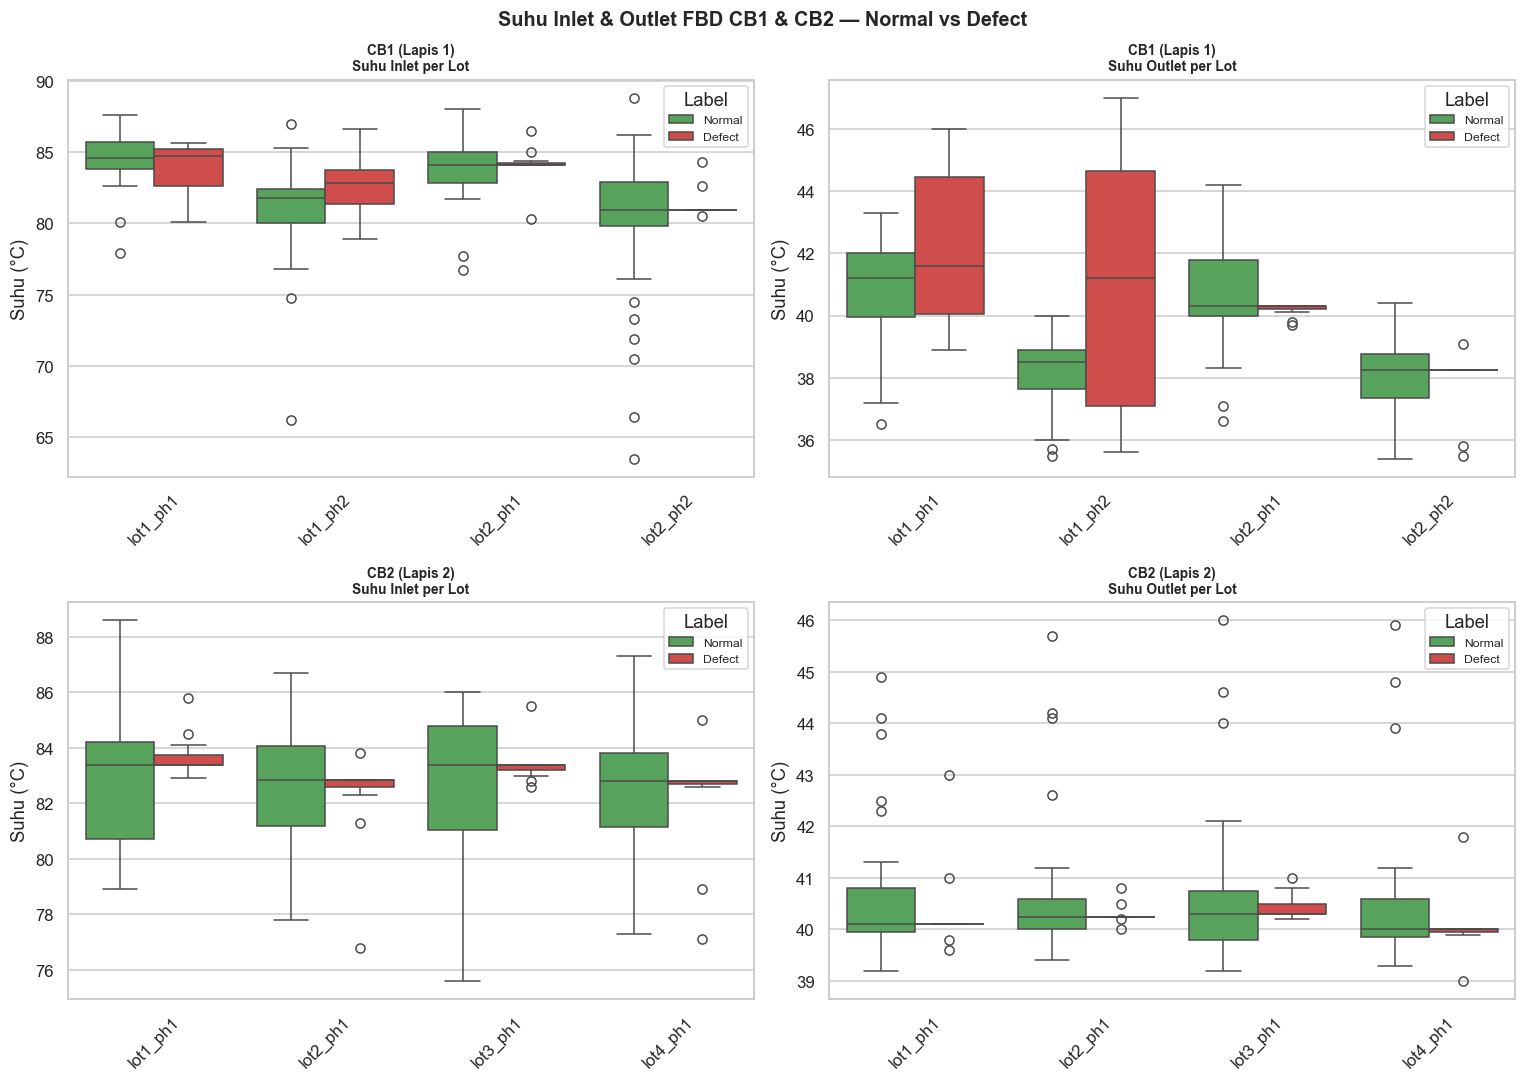

Statistik Inlet CB1:
           cb1_inlet_lot1_ph1  cb1_inlet_lot1_ph2  cb1_inlet_lot2_ph1  cb1_inlet_lot2_ph2
is_defect                                                                                
Normal                  84.48               81.01               83.63               79.81
Defect                  83.77               82.61               84.08               81.36

Statistik Outlet CB2:
           cb2_outlet_lot1_ph1  cb2_outlet_lot2_ph1  cb2_outlet_lot3_ph1  cb2_outlet_lot4_ph1
is_defect                                                                                    
Normal                   40.63                40.66                40.65                40.55
Defect                   40.37                40.30                40.44                40.05


In [23]:
# Inlet & Outlet suhu FBD
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Suhu Inlet & Outlet FBD CB1 & CB2 — Normal vs Defect',
             fontsize=13, fontweight='bold')

for r_idx, (lapis, prefix) in enumerate([('CB1 (Lapis 1)', 'cb1'), ('CB2 (Lapis 2)', 'cb2')]):
    inlet_cols  = [c for c in df.columns if c.startswith(f'{prefix}_inlet')]
    outlet_cols = [c for c in df.columns if c.startswith(f'{prefix}_outlet')]

    for c_idx, (io_cols, io_label) in enumerate([(inlet_cols, 'Inlet'), (outlet_cols, 'Outlet')]):
        ax = axes[r_idx, c_idx]
        if io_cols:
            df_io = df[io_cols + ['is_defect']].melt(id_vars='is_defect',
                                                       var_name='lot', value_name='suhu')
            df_io['Label'] = df_io['is_defect'].map(LABEL_MAP)
            df_io['lot'] = df_io['lot'].str.replace(f'{prefix}_{io_label.lower()}_', '', regex=False)
            sns.boxplot(data=df_io, x='lot', y='suhu', hue='Label',
                        palette={LABEL_MAP[k]: v for k, v in PALETTE.items()}, ax=ax, linewidth=1.0)
            ax.set_ylabel('Suhu (°C)')
            ax.tick_params(axis='x', rotation=45)
            ax.legend(title='Label', fontsize=8)
        else:
            ax.text(0.5,0.5,'Data tidak tersedia',ha='center',va='center',transform=ax.transAxes)
        ax.set_title(f'{lapis}\nSuhu {io_label} per Lot', fontweight='bold', fontsize=9)
        ax.set_xlabel('')

plt.tight_layout()
plt.savefig("outputs/eda_plot_12.png", dpi=150, bbox_inches="tight")
plt.show()

print('Statistik Inlet CB1:')
cb1_inlet = [c for c in df.columns if c.startswith('cb1_inlet')]
if cb1_inlet:
    print(df.groupby('is_defect')[cb1_inlet].mean().rename(index=LABEL_MAP).round(2).to_string())
print()
print('Statistik Outlet CB2:')
cb2_outlet = [c for c in df.columns if c.startswith('cb2_outlet')]
if cb2_outlet:
    print(df.groupby('is_defect')[cb2_outlet].mean().rename(index=LABEL_MAP).round(2).to_string())

---
## 8. Peta Korelasi Fitur dengan Label Defect

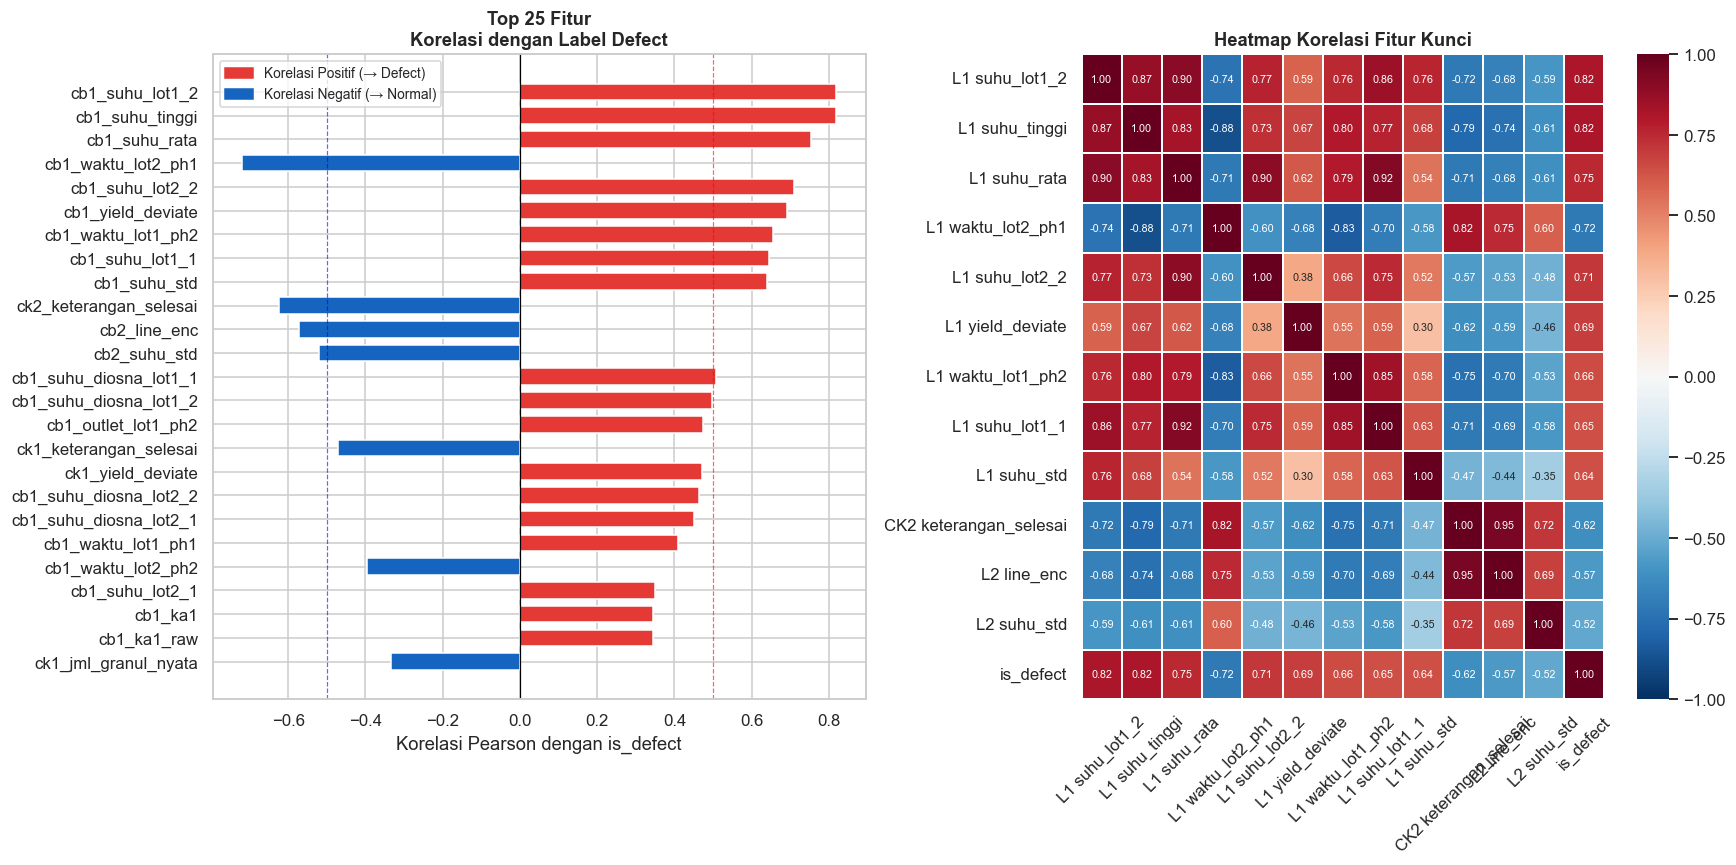


Top 10 berkorelasi POSITIF (→ cenderung Defect):
cb1_suhu_lot1_2           0.8186
cb1_suhu_tinggi           0.8184
cb1_suhu_rata             0.7541
cb1_suhu_lot2_2           0.7098
cb1_yield_deviate         0.6908
cb1_waktu_lot1_ph2        0.6552
cb1_suhu_lot1_1           0.6460
cb1_suhu_std              0.6410
cb1_suhu_diosna_lot1_1    0.5078
cb1_suhu_diosna_lot1_2    0.4982

Top 10 berkorelasi NEGATIF (→ cenderung Normal):
cb1_waktu_lot2_ph1       -0.7185
ck2_keterangan_selesai   -0.6228
cb2_line_enc             -0.5722
cb2_suhu_std             -0.5208
ck1_keterangan_selesai   -0.4719
cb1_waktu_lot2_ph2       -0.3957
ck1_jml_granul_nyata     -0.3347
cb1_jml_granul_kg        -0.3100
cb1_pct_yield            -0.3100
cb2_waktu_lot3_ph1       -0.2997


In [24]:
# Korelasi semua fitur numerik vs is_defect
numeric_feats = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_feats = [c for c in numeric_feats if c not in ['is_defect','excel_row']]

corr_series = {}
for col in numeric_feats:
    valid = df[[col,'is_defect']].dropna()
    if len(valid) >= 5 and valid[col].nunique() > 1:
        corr_series[col] = valid[col].corr(valid['is_defect'])

corr_df = pd.DataFrame.from_dict(corr_series, orient='index', columns=['correlation'])
corr_df['abs_corr'] = corr_df['correlation'].abs()
corr_df = corr_df.sort_values('abs_corr', ascending=False)

# Bar chart top 25
top25 = corr_df.head(25)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
colors_bar = ['#E53935' if v > 0 else '#1565C0' for v in top25['correlation']]
axes[0].barh(top25.index[::-1], top25['correlation'].values[::-1],
             color=colors_bar[::-1], edgecolor='white', height=0.7)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].axvline( 0.5, color='red',  linestyle='--', lw=0.8, alpha=0.6)
axes[0].axvline(-0.5, color='blue', linestyle='--', lw=0.8, alpha=0.6)
axes[0].set_xlabel('Korelasi Pearson dengan is_defect')
axes[0].set_title('Top 25 Fitur\nKorelasi dengan Label Defect', fontweight='bold')
red_p  = mpatches.Patch(color='#E53935', label='Korelasi Positif (→ Defect)')
blue_p = mpatches.Patch(color='#1565C0', label='Korelasi Negatif (→ Normal)')
axes[0].legend(handles=[red_p, blue_p], fontsize=9)

# Heatmap top 12 fitur
top12 = corr_df.head(12).index.tolist() + ['is_defect']
corr_mat = df[top12].corr()
short_names = {c: c.replace('cb1_','L1 ').replace('cb2_','L2 ').replace('ck1_','CK1 ').replace('ck2_','CK2 ')
               for c in top12}
sns.heatmap(corr_mat.rename(index=short_names, columns=short_names),
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[1], linewidths=0.3,
            annot_kws={'size': 7})
axes[1].set_title('Heatmap Korelasi Fitur Kunci', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig("outputs/eda_plot_13.png", dpi=150, bbox_inches="tight")
plt.show()

print('\nTop 10 berkorelasi POSITIF (→ cenderung Defect):')
print(corr_df[corr_df.correlation > 0].head(10)['correlation'].round(4).to_string())
print()
print('Top 10 berkorelasi NEGATIF (→ cenderung Normal):')
print(corr_df[corr_df.correlation < 0].head(10)['correlation'].round(4).to_string())

In [25]:
# Fitur berkorelasi sangat tinggi satu sama lain (potential redundancy)
corr_matrix_all = df[numeric_feats].corr()
high_corr = []
for i in range(len(corr_matrix_all.columns)):
    for j in range(i):
        val = corr_matrix_all.iloc[i, j]
        if abs(val) > 0.85:
            high_corr.append({
                'Feature 1': corr_matrix_all.columns[i],
                'Feature 2': corr_matrix_all.columns[j],
                'Correlation': round(val, 4)
            })
high_corr_df = pd.DataFrame(high_corr).sort_values('Correlation', key=abs, ascending=False)
print(f'Pasangan fitur dengan |korelasi| > 0.85: {len(high_corr_df)}')
if len(high_corr_df):
    print(high_corr_df.to_string(index=False))
print('\n→ Fitur di atas berisiko multikollinearitas — pertimbangkan untuk drop salah satu.')

Pasangan fitur dengan |korelasi| > 0.85: 38
             Feature 1              Feature 2  Correlation
 ck1_ka_setelah_ck_raw      ck1_ka_setelah_ck       1.0000
           cb2_ka4_raw                cb2_ka4       1.0000
           cb2_ka3_raw                cb2_ka3       1.0000
         cb1_pct_yield      cb1_jml_granul_kg       1.0000
           cb2_ka2_raw                cb2_ka2       1.0000
           cb2_ka1_raw                cb2_ka1       1.0000
           cb1_ka1_raw                cb1_ka1       1.0000
      ka_ekstrem_count        cb1_ka2_ekstrem       1.0000
           cb1_ka2_raw       ka_ekstrem_count       0.9999
           cb1_ka2_raw        cb1_ka2_ekstrem       0.9999
     cb2_yield_deviate          cb2_pct_yield      -0.9985
    cb2_waktu_lot2_ph1     cb2_waktu_lot1_ph1       0.9916
    cb2_waktu_lot4_ph1     cb2_waktu_lot3_ph1       0.9850
   cb2_outlet_lot3_ph1    cb2_outlet_lot2_ph1       0.9557
ck2_keterangan_selesai           cb2_line_enc       0.9520
   cb2_outle

---
## 9. Threshold Defect per Parameter

Definisi threshold berdasarkan analisis data untuk **semua tahap proses**  
(CB1, CK1, CB2, CK2). Suatu batch dinyatakan **berisiko defect** jika  
satu atau lebih parameter berikut dilanggar.

In [26]:
THRESHOLDS = {
    # CB1: Granulasi Basah Lapis 1
    'CB1 | Suhu Decoct Rata-rata Tinggi'   : {'col': 'cb1_suhu_rata',       'op': '>',  'val': 75.0,  'unit': '°C'},
    'CB1 | KA Lot 1 Terlalu Tinggi'        : {'col': 'cb1_ka1',             'op': '>',  'val': 5.5,   'unit': '%'},
    'CB1 | KA Lot 2 Terlalu Tinggi'        : {'col': 'cb1_ka2',             'op': '>',  'val': 5.5,   'unit': '%'},
    'CB1 | KA Lot 1 Terlalu Rendah'        : {'col': 'cb1_ka1',             'op': '<',  'val': 3.0,   'unit': '%'},
    'CB1 | Yield Terlalu Rendah'           : {'col': 'cb1_pct_yield',       'op': '<',  'val': 99.0,  'unit': '%'},
    'CB1 | Yield Terlalu Tinggi'           : {'col': 'cb1_pct_yield',       'op': '>',  'val': 103.1, 'unit': '%'},

    # CK1: Campur Kering Lapis 1
    'CK1 | KA setelah CK Terlalu Tinggi'  : {'col': 'ck1_ka_setelah_ck',   'op': '>',  'val': 5.5,   'unit': '%'},
    'CK1 | Yield Terlalu Rendah'          : {'col': 'ck1_pct_yield',       'op': '<',  'val': 99.1,  'unit': '%'},

    # CB2: Granulasi Basah Lapis 2
    'CB2 | Suhu Decoct Rata-rata Tinggi'   : {'col': 'cb2_suhu_rata',       'op': '>',  'val': 75.0,  'unit': '°C'},
    'CB2 | KA Lot 1 Terlalu Tinggi'        : {'col': 'cb2_ka1',             'op': '>',  'val': 5.5,   'unit': '%'},
    'CB2 | KA Lot 2 Terlalu Tinggi'        : {'col': 'cb2_ka2',             'op': '>',  'val': 5.5,   'unit': '%'},
    'CB2 | KA Lot 3 Terlalu Tinggi'        : {'col': 'cb2_ka3',             'op': '>',  'val': 5.5,   'unit': '%'},
    'CB2 | KA Lot 4 Terlalu Tinggi'        : {'col': 'cb2_ka4',             'op': '>',  'val': 5.5,   'unit': '%'},
    'CB2 | KA Rata-rata Terlalu Rendah'    : {'col': 'cb2_rata_ka',         'op': '<',  'val': 3.0,   'unit': '%'},
    'CB2 | Yield Terlalu Rendah'           : {'col': 'cb2_pct_yield',       'op': '<',  'val': 99.1,  'unit': '%'},
    'CB2 | Yield Terlalu Tinggi'           : {'col': 'cb2_pct_yield',       'op': '>',  'val': 102.3, 'unit': '%'},

    # CK2: Campur Kering Lapis 2
    'CK2 | KA setelah CK Terlalu Tinggi'  : {'col': 'ck2_ka_setelah_ck',   'op': '>',  'val': 5.5,   'unit': '%'},
    'CK2 | Yield Terlalu Rendah'          : {'col': 'ck2_pct_yield',       'op': '<',  'val': 99.1,  'unit': '%'},
}

print('{:<45} {:<22} {:>12} {:>12}'.format('Parameter', 'Threshold', 'Defect', 'Normal'))
print('─' * 95)

total_def = (df.is_defect == 1).sum()
total_nor = (df.is_defect == 0).sum()

for name, cfg in THRESHOLDS.items():
    col = cfg['col']
    if col not in df.columns:
        continue
    op, val = cfg['op'], cfg['val']
    flagged = (df[col] > val) if op == '>' else (df[col] < val)
    n_d = flagged[df.is_defect == 1].sum()
    n_n = flagged[df.is_defect == 0].sum()
    th_str  = f'{op} {val} {cfg["unit"]}'
    pct_d = f'{n_d}/{total_def} ({n_d/total_def*100:.0f}%)'
    pct_n = f'{n_n}/{total_nor} ({n_n/total_nor*100:.0f}%)'
    print(f'{name:<45} {th_str:<22} {pct_d:>12} {pct_n:>12}')

Parameter                                     Threshold                    Defect       Normal
───────────────────────────────────────────────────────────────────────────────────────────────
CB1 | Suhu Decoct Rata-rata Tinggi            > 75.0 °C                8/11 (73%)    0/35 (0%)
CB1 | KA Lot 1 Terlalu Tinggi                 > 5.5 %                   0/11 (0%)    0/35 (0%)
CB1 | KA Lot 2 Terlalu Tinggi                 > 5.5 %                   0/11 (0%)    0/35 (0%)
CB1 | KA Lot 1 Terlalu Rendah                 < 3.0 %                   0/11 (0%)    0/35 (0%)
CB1 | Yield Terlalu Rendah                    < 99.0 %                 3/11 (27%)    0/35 (0%)
CB1 | Yield Terlalu Tinggi                    > 103.1 %                3/11 (27%)    0/35 (0%)
CK1 | KA setelah CK Terlalu Tinggi            > 5.5 %                   1/11 (9%)    0/35 (0%)
CK1 | Yield Terlalu Rendah                    < 99.1 %                 2/11 (18%)    0/35 (0%)
CB2 | Suhu Decoct Rata-rata Tinggi            > 7

Distribusi jumlah pelanggaran threshold per batch:

  Normal:
    Rata-rata pelanggaran  : 0.00
    Maks pelanggaran       : 0
    Batch ≥1 pelanggaran   : 0 dari 35 (0%)

  Defect:
    Rata-rata pelanggaran  : 1.64
    Maks pelanggaran       : 3
    Batch ≥1 pelanggaran   : 9 dari 11 (82%)



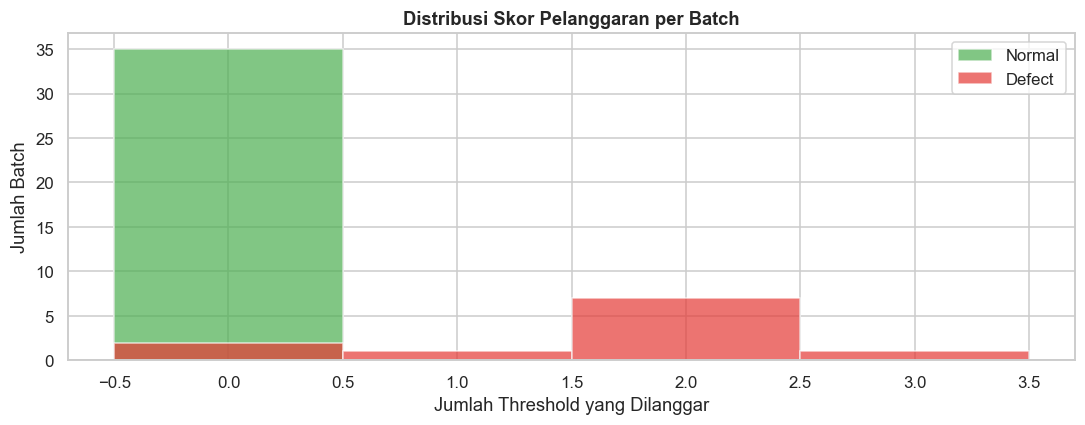

In [27]:
# Skor pelanggaran threshold per batch
df_flag = df.copy()
flag_cols = []
for name, cfg in THRESHOLDS.items():
    col = cfg['col']
    if col not in df_flag.columns:
        continue
    op, val = cfg['op'], cfg['val']
    fcol = 'flag_' + name.replace(' | ', '_').replace(' ', '_')[:35]
    df_flag[fcol] = ((df_flag[col] > val) if op == '>' else (df_flag[col] < val)).astype(int)
    flag_cols.append(fcol)

df_flag['violation_score'] = df_flag[flag_cols].sum(axis=1)

print('Distribusi jumlah pelanggaran threshold per batch:')
print()
for label in [0, 1]:
    sub = df_flag[df_flag.is_defect == label]['violation_score']
    print(f'  {LABEL_MAP[label]}:')
    print(f'    Rata-rata pelanggaran  : {sub.mean():.2f}')
    print(f'    Maks pelanggaran       : {sub.max()}')
    print(f'    Batch ≥1 pelanggaran   : {(sub >= 1).sum()} dari {len(sub)} ({(sub >= 1).mean()*100:.0f}%)')
    print()

# Visualisasi skor pelanggaran
fig, ax = plt.subplots(figsize=(10, 4))
for label in [0, 1]:
    sub = df_flag[df_flag.is_defect == label]['violation_score']
    ax.hist(sub, bins=range(0, int(sub.max())+2), alpha=0.7, color=PALETTE[label],
            label=LABEL_MAP[label], edgecolor='white', align='left')
ax.set_xlabel('Jumlah Threshold yang Dilanggar')
ax.set_ylabel('Jumlah Batch')
ax.set_title('Distribusi Skor Pelanggaran per Batch', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("outputs/eda_plot_14.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 10. Analisis Alasan Defect Per Batch (Rule-Based Explanation)

Untuk setiap batch defect, ditampilkan **alasan spesifik** berdasarkan parameter  
yang melampaui threshold di **semua tahap proses: CB1, CK1, CB2, CK2**.

In [28]:
def generate_defect_reasons(row):
    """
    Menghasilkan daftar alasan defect berdasarkan parameter yang melampaui
    threshold di semua tahap proses (CB1, CK1, CB2, CK2).
    """
    reasons = []

    # CB1: Suhu Decoct
    if pd.notna(row.get('cb1_suhu_rata')) and row['cb1_suhu_rata'] > 75.0:
        reasons.append(
            f"[CB1] Suhu decoct rata-rata terlalu tinggi ({row['cb1_suhu_rata']:.1f}°C > 75.0°C)")
    for lot in ['cb1_suhu_lot1_1','cb1_suhu_lot1_2','cb1_suhu_lot2_1','cb1_suhu_lot2_2']:
        if lot in row.index and pd.notna(row[lot]) and row[lot] > 75.0:
            label = lot.replace('cb1_suhu_','').replace('_','/')
            reasons.append(f"[CB1] Suhu decoct {label} tinggi ({row[lot]:.1f}°C > 75°C)")

    # CB1: KA
    for ka_col, ka_name in [('cb1_ka1','KA Lot 1'),('cb1_ka2','KA Lot 2'),('cb1_rata_ka','KA Rata-rata')]:
        if ka_col in row.index and pd.notna(row[ka_col]):
            v = row[ka_col]
            if v > 10:
                reasons.append(f"[CB1] {ka_name} ekstrem/error ({v:.2f}%)")
            elif v > 5.5:
                reasons.append(f"[CB1] {ka_name} terlalu tinggi ({v:.2f}% > 5.5%)")
            elif v < 3.0:
                reasons.append(f"[CB1] {ka_name} terlalu rendah ({v:.2f}% < 4.5%)")

    # CB1: Yield
    if 'cb1_pct_yield' in row.index and pd.notna(row['cb1_pct_yield']):
        v = row['cb1_pct_yield']
        if v < 99.0:
            reasons.append(f"[CB1] % Yield terlalu rendah ({v:.2f}% < 99.0%)")
        elif v > 103.1:
            reasons.append(f"[CB1] % Yield terlalu tinggi ({v:.2f}% > 103.1%)")

    # CK1: KA & Yield
    if 'ck1_ka_setelah_ck' in row.index and pd.notna(row['ck1_ka_setelah_ck']):
        v = row['ck1_ka_setelah_ck']
        if v > 5.5:
            reasons.append(f"[CK1] KA setelah Campur Kering tinggi ({v:.2f}% > 5.5%)")
        elif v < 3.0:
            reasons.append(f"[CK1] KA setelah Campur Kering rendah ({v:.2f}% < 4.5%)")
    if 'ck1_pct_yield' in row.index and pd.notna(row['ck1_pct_yield']):
        v = row['ck1_pct_yield']
        if v < 99.1:
            reasons.append(f"[CK1] % Yield terlalu rendah ({v:.2f}% < 99.1%)")
        elif v > 102.9:
            reasons.append(f"[CK1] % Yield terlalu tinggi ({v:.2f}% > 102.9%)")
    if row.get('ck1_keterangan_selesai', 1) == 0:
        reasons.append("[CK1] Status keterangan tidak 'SELESAI' — proses belum tuntas")

    # CB2: Suhu Decoct
    if pd.notna(row.get('cb2_suhu_rata')) and row['cb2_suhu_rata'] > 75.0:
        reasons.append(
            f"[CB2] Suhu decoct rata-rata terlalu tinggi ({row['cb2_suhu_rata']:.1f}°C > 75.0°C)")
    for lot in ['cb2_suhu_lot1_1','cb2_suhu_lot1_2','cb2_suhu_lot2_1','cb2_suhu_lot2_2',
                'cb2_suhu_lot3_1','cb2_suhu_lot3_2','cb2_suhu_lot4_1','cb2_suhu_lot4_2']:
        if lot in row.index and pd.notna(row[lot]) and row[lot] > 75.0:
            label = lot.replace('cb2_suhu_','').replace('_','/')
            reasons.append(f"[CB2] Suhu decoct {label} tinggi ({row[lot]:.1f}°C > 75°C)")

    # CB2: KA
    for ka_col, ka_name in [
        ('cb2_ka1','KA Lot 1'),('cb2_ka2','KA Lot 2'),
        ('cb2_ka3','KA Lot 3'),('cb2_ka4','KA Lot 4'),
        ('cb2_rata_ka','KA Rata-rata'),
    ]:
        if ka_col in row.index and pd.notna(row[ka_col]):
            v = row[ka_col]
            if v > 10:
                reasons.append(f"[CB2] {ka_name} ekstrem/error ({v:.2f}%)")
            elif v > 5.5:
                reasons.append(f"[CB2] {ka_name} terlalu tinggi ({v:.2f}% > 5.5%)")
            elif v < 3.0:
                reasons.append(f"[CB2] {ka_name} terlalu rendah ({v:.2f}% < 3.0%)")

    # CB2: Yield
    if 'cb2_pct_yield' in row.index and pd.notna(row['cb2_pct_yield']):
        v = row['cb2_pct_yield']
        if v < 99.1:
            reasons.append(f"[CB2] % Yield terlalu rendah ({v:.2f}% < 99.1%)")
        elif v > 102.3:
            reasons.append(f"[CB2] % Yield terlalu tinggi ({v:.2f}% > 102.3%)")

    # CK2: KA & Yield
    if 'ck2_ka_setelah_ck' in df.columns and 'ck2_ka_setelah_ck' in row.index and pd.notna(row['ck2_ka_setelah_ck']):
        v = row['ck2_ka_setelah_ck']
        if v > 5.5:
            reasons.append(f"[CK2] KA setelah Campur Kering tinggi ({v:.2f}% > 5.5%)")
    if 'ck2_pct_yield' in df.columns and 'ck2_pct_yield' in row.index and pd.notna(row['ck2_pct_yield']):
        v = row['ck2_pct_yield']
        if v < 99.1:
            reasons.append(f"[CK2] % Yield terlalu rendah ({v:.2f}% < 99.1%)")
    if row.get('ck2_keterangan_selesai', 1) == 0:
        reasons.append("[CK2] Status keterangan tidak 'SELESAI' — proses belum tuntas")

    # Faktor lain
    if pd.isna(row.get('batch_ke')):
        reasons.append("[INFO] Nomor batch kosong — baris sub-lapis tanpa batch number")

    return reasons


# Tampilkan alasan untuk setiap batch defect
print('=' * 75)
print('  ALASAN DEFECT PER BATCH (CB1, CK1, CB2, CK2)')
print('=' * 75)

defect_rows = df[df.is_defect == 1].copy()
for idx, row in defect_rows.iterrows():
    batch_info = f"Batch {int(row['batch_ke']) if pd.notna(row.get('batch_ke')) else 'N/A'}"
    print(f"\n[Baris {idx+1}] {row.get('material_desc','?')} | {batch_info}")
    reasons = generate_defect_reasons(row)
    if reasons:
        for r in reasons:
            print(f'  ⚠  {r}')
    else:
        print('  ℹ  Semua parameter dalam batas numerik — '
              'kemungkinan defect karena faktor non-numerik (catatan operator, dll)')

  ALASAN DEFECT PER BATCH (CB1, CK1, CB2, CK2)

[Baris 2] BODREX FLU & BATUK PE/4'S | Batch 5
  ⚠  [CB1] Suhu decoct rata-rata terlalu tinggi (78.2°C > 75.0°C)
  ⚠  [CB1] Suhu decoct lot1/1 tinggi (80.4°C > 75°C)
  ⚠  [CB1] Suhu decoct lot1/2 tinggi (80.9°C > 75°C)
  ⚠  [CB1] Suhu decoct lot2/2 tinggi (80.6°C > 75°C)
  ⚠  [CK1] KA setelah Campur Kering tinggi (5.57% > 5.5%)
  ⚠  [CK2] Status keterangan tidak 'SELESAI' — proses belum tuntas

[Baris 4] BODREX FLU & BATUK PE/4'S | Batch 5
  ⚠  [CB1] Suhu decoct rata-rata terlalu tinggi (77.3°C > 75.0°C)
  ⚠  [CB1] Suhu decoct lot1/1 tinggi (80.3°C > 75°C)
  ⚠  [CB1] Suhu decoct lot1/2 tinggi (80.8°C > 75°C)
  ⚠  [CB1] % Yield terlalu rendah (94.86% < 99.0%)
  ⚠  [CK1] % Yield terlalu rendah (94.98% < 99.1%)
  ⚠  [CK2] Status keterangan tidak 'SELESAI' — proses belum tuntas

[Baris 10] BODREX FLU & BATUK PE/4'S | Batch 5
  ⚠  [CB1] Suhu decoct rata-rata terlalu tinggi (78.0°C > 75.0°C)
  ⚠  [CB1] Suhu decoct lot1/1 tinggi (78.0°C > 75°C)
 

In [29]:
# Ringkasan: alasan defect paling sering muncul
from collections import Counter

all_reasons = []
for _, row in defect_rows.iterrows():
    reasons = generate_defect_reasons(row)
    # Ekstrak kategori alasan (prefix saja)
    for r in reasons:
        category = r.split(']')[0] + '] ' + ' '.join(r.split(']')[1].strip().split()[:4])
        all_reasons.append(category)

reason_counts = Counter(all_reasons)

print('Alasan defect yang paling sering muncul:')
print()
for reason, cnt in reason_counts.most_common(15):
    bar = '█' * cnt
    print(f'  {cnt:2d}x  {bar:15s}  {reason}')

Alasan defect yang paling sering muncul:

  10x  ██████████       [CB1] Suhu decoct lot1/2 tinggi
   8x  ████████         [CB1] Suhu decoct rata-rata terlalu
   8x  ████████         [CB1] Suhu decoct lot2/2 tinggi
   7x  ███████          [CK2] Status keterangan tidak 'SELESAI'
   6x  ██████           [CB1] Suhu decoct lot1/1 tinggi
   5x  █████            [CK1] Status keterangan tidak 'SELESAI'
   4x  ████             [CB1] Suhu decoct lot2/1 tinggi
   3x  ███              [CB1] % Yield terlalu rendah
   3x  ███              [CB1] % Yield terlalu tinggi
   2x  ██               [CK1] % Yield terlalu rendah
   1x  █                [CK1] KA setelah Campur Kering
   1x  █                [CB2] % Yield terlalu rendah
   1x  █                [CK1] % Yield terlalu tinggi


---
## 11. Feature Importance & Visualisasi Multi-Fitur

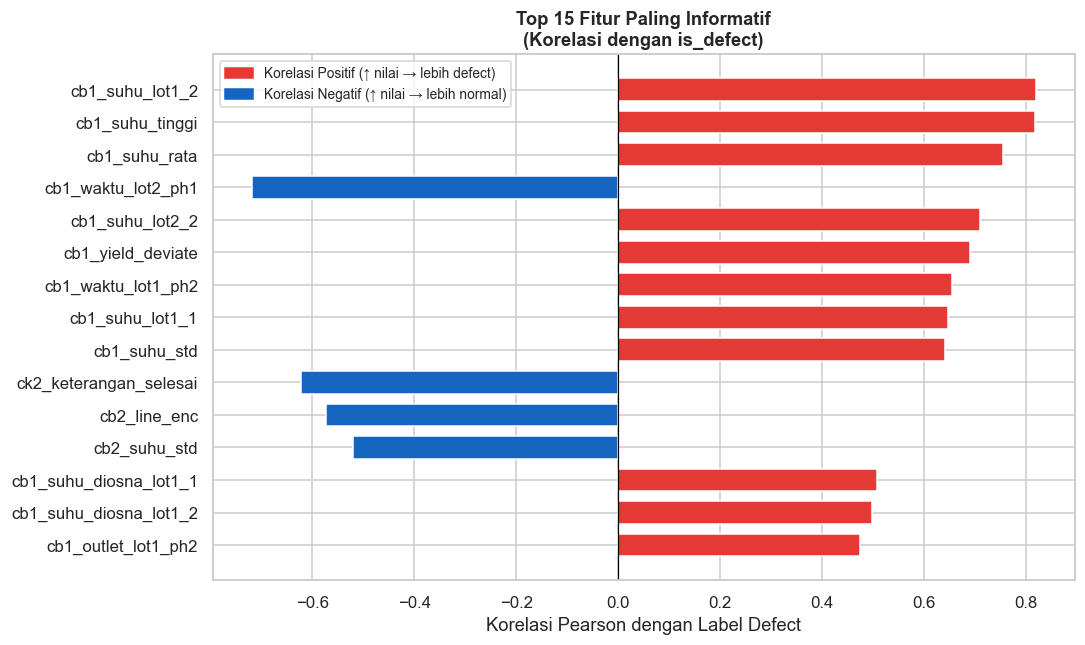


Top 10 fitur untuk modeling:
   1. cb1_suhu_lot1_2                               r = +0.8186
   2. cb1_suhu_tinggi                               r = +0.8184
   3. cb1_suhu_rata                                 r = +0.7541
   4. cb1_waktu_lot2_ph1                            r = -0.7185
   5. cb1_suhu_lot2_2                               r = +0.7098
   6. cb1_yield_deviate                             r = +0.6908
   7. cb1_waktu_lot1_ph2                            r = +0.6552
   8. cb1_suhu_lot1_1                               r = +0.6460
   9. cb1_suhu_std                                  r = +0.6410
  10. ck2_keterangan_selesai                        r = -0.6228


In [30]:
# Top 15 fitur paling informatif
top15 = corr_df.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors_b = ['#E53935' if v > 0 else '#1565C0' for v in top15['correlation']]
ax.barh(top15.index[::-1], top15['correlation'].values[::-1],
        color=colors_b[::-1], edgecolor='white', height=0.7)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Korelasi Pearson dengan Label Defect')
ax.set_title('Top 15 Fitur Paling Informatif\n(Korelasi dengan is_defect)',
             fontweight='bold')
red_p  = mpatches.Patch(color='#E53935', label='Korelasi Positif (↑ nilai → lebih defect)')
blue_p = mpatches.Patch(color='#1565C0', label='Korelasi Negatif (↑ nilai → lebih normal)')
ax.legend(handles=[red_p, blue_p], fontsize=9)
plt.tight_layout()
plt.savefig("outputs/eda_plot_15.png", dpi=150, bbox_inches="tight")
plt.show()

print('\nTop 10 fitur untuk modeling:')
for i, (feat, row_) in enumerate(corr_df.head(10).iterrows(), 1):
    print(f'  {i:2d}. {feat:<45} r = {row_["correlation"]:+.4f}')

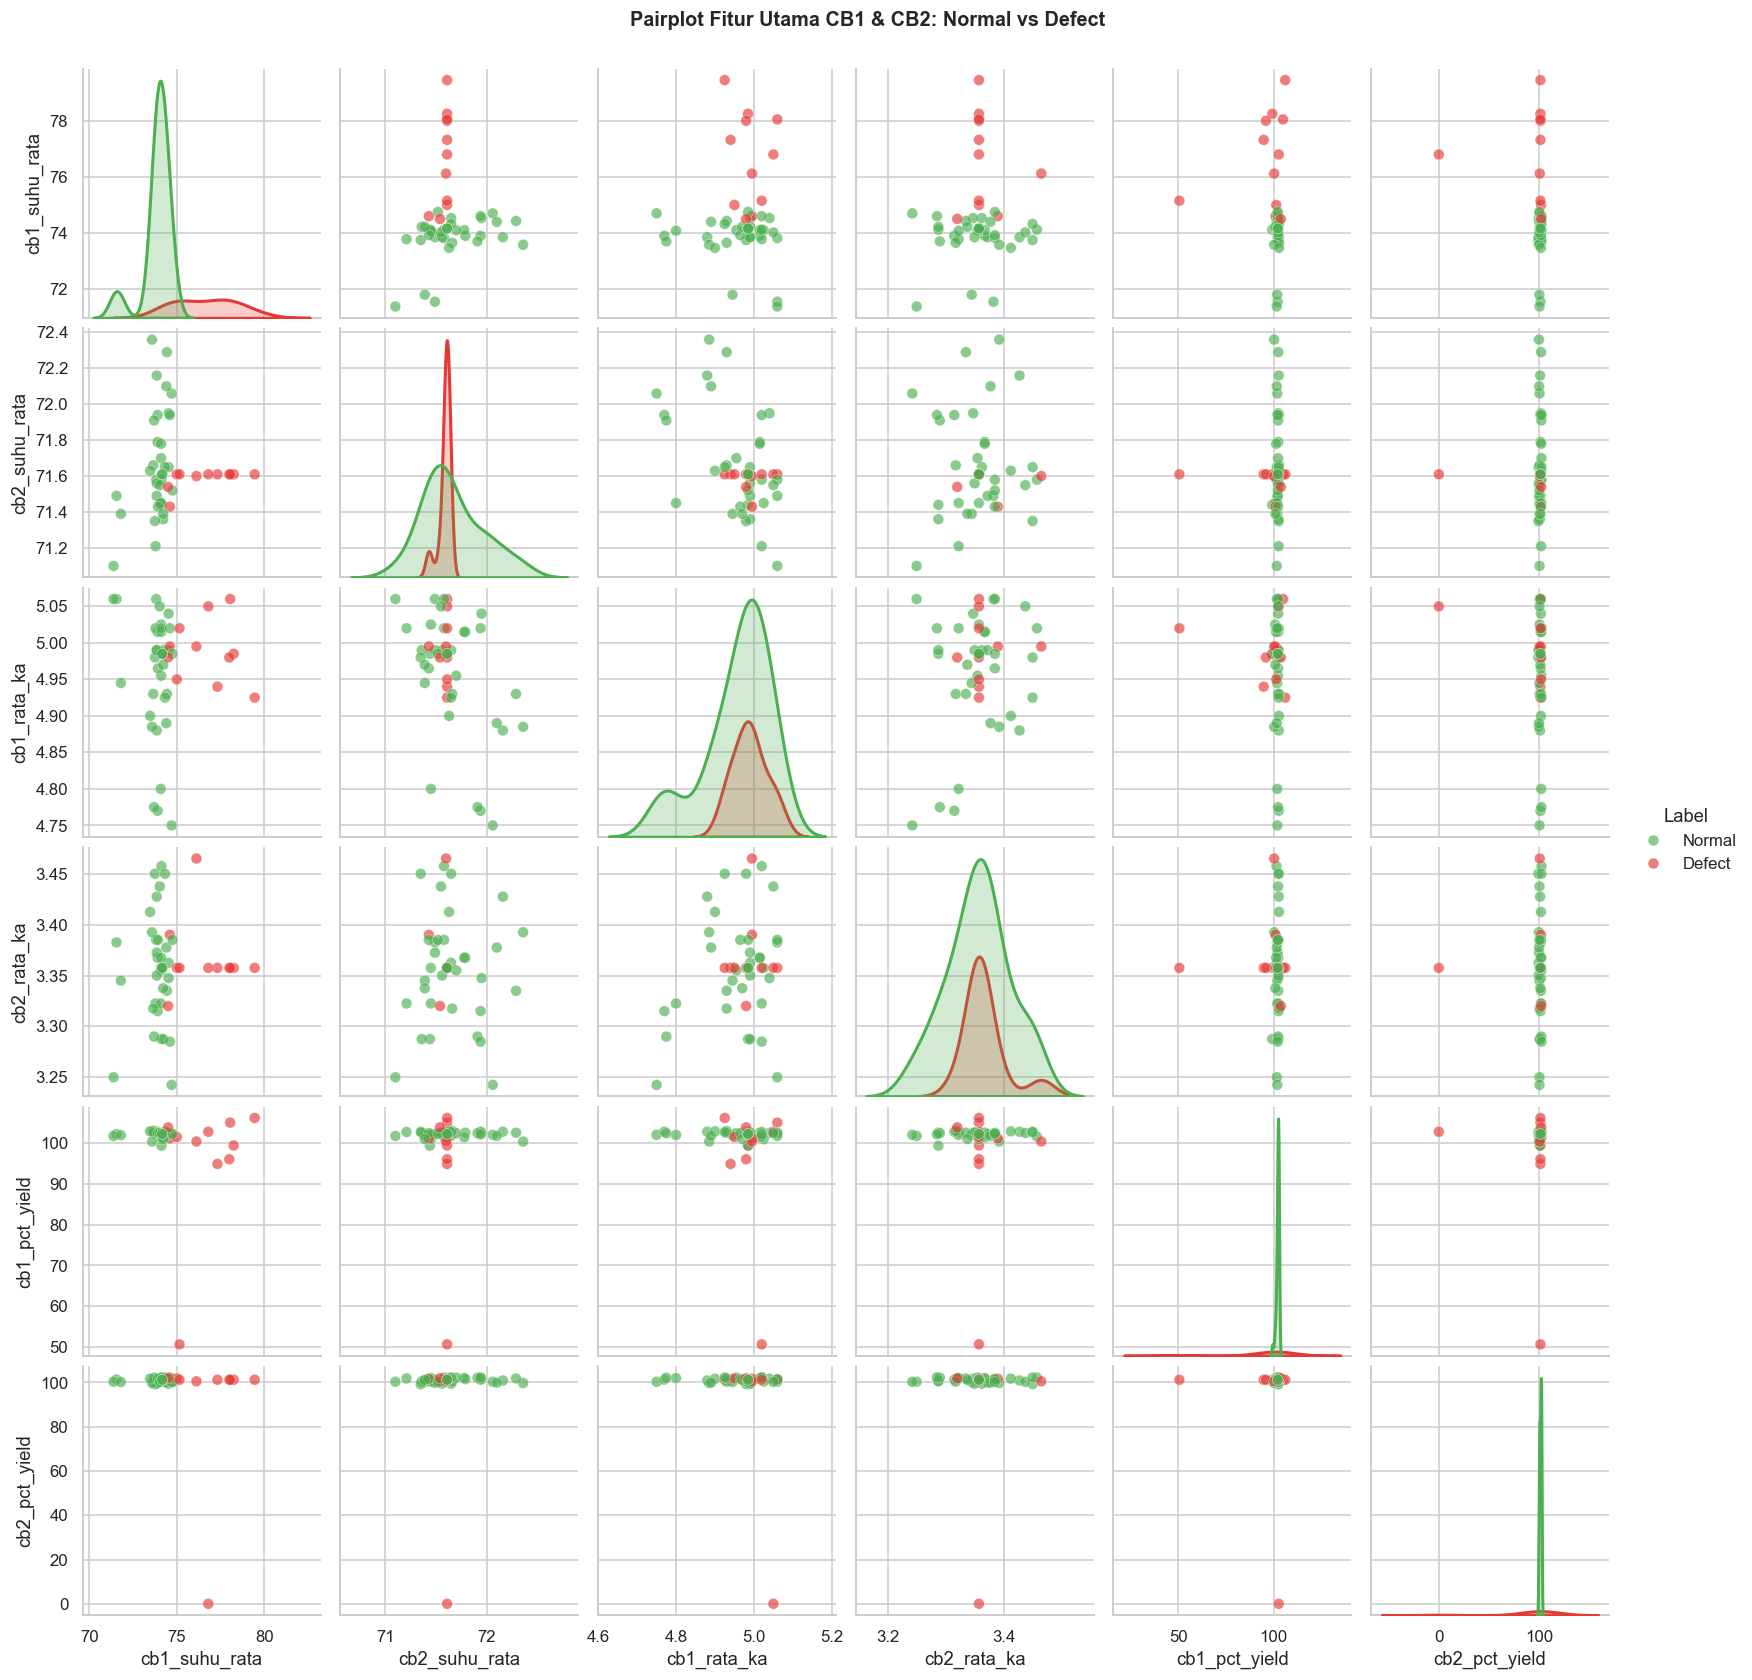

In [31]:
# Pairplot fitur utama (CB1 + CB2)
key_features = ['cb1_suhu_rata','cb2_suhu_rata',
                'cb1_rata_ka',  'cb2_rata_ka',
                'cb1_pct_yield','cb2_pct_yield', 'is_defect']
key_features = [c for c in key_features if c in df.columns]

plot_df = df[key_features].dropna().copy()
plot_df['Label'] = plot_df['is_defect'].map(LABEL_MAP)

g = sns.pairplot(plot_df.drop(columns=['is_defect']),
                 hue='Label',
                 palette={'Normal': PALETTE[0], 'Defect': PALETTE[1]},
                 diag_kind='kde',
                 plot_kws={'alpha': 0.65, 's': 50, 'edgecolor': 'white', 'linewidth': 0.3},
                 diag_kws={'linewidth': 2})
g.figure.suptitle('Pairplot Fitur Utama CB1 & CB2: Normal vs Defect',
                   y=1.02, fontsize=13, fontweight='bold')
plt.savefig("outputs/eda_plot_16.png", dpi=150, bbox_inches="tight")
plt.show()

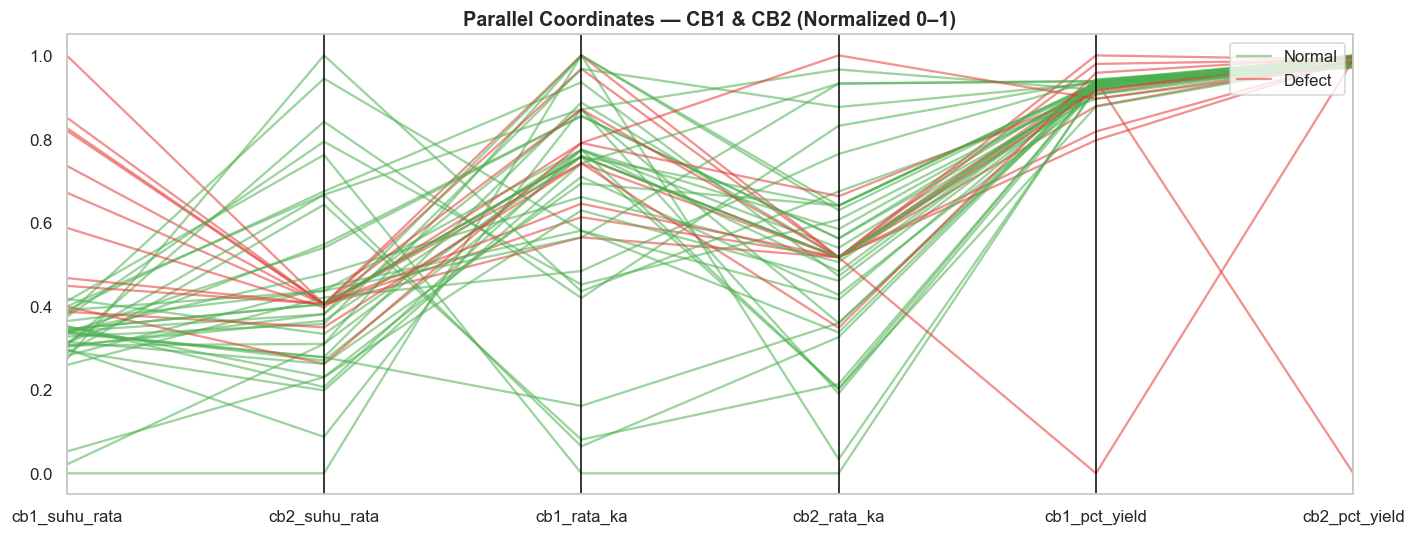

In [32]:
# Parallel Coordinates, fitur utama dinormalisasi
pc_cols = ['cb1_suhu_rata','cb2_suhu_rata',
           'cb1_rata_ka','cb2_rata_ka',
           'cb1_pct_yield','cb2_pct_yield']
pc_cols = [c for c in pc_cols if c in df.columns]

pc_df = df[pc_cols + ['is_defect']].dropna().copy()
for c in pc_cols:
    mn, mx = pc_df[c].min(), pc_df[c].max()
    pc_df[c] = (pc_df[c] - mn) / (mx - mn + 1e-9)
pc_df['Label'] = pc_df['is_defect'].map(LABEL_MAP)

fig, ax = plt.subplots(figsize=(13, 5))
parallel_coordinates(pc_df.drop(columns=['is_defect']), 'Label',
                     color=[PALETTE[0], PALETTE[1]],
                     ax=ax, alpha=0.55, linewidth=1.5)
ax.set_title('Parallel Coordinates — CB1 & CB2 (Normalized 0–1)',
             fontweight='bold', fontsize=13)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig("outputs/eda_plot_17.png", dpi=150, bbox_inches="tight")
plt.show()

In [33]:
# Simpan daftar fitur terpilih
selected_features = corr_df[corr_df['abs_corr'] > 0.05].index.tolist()
print(f'Total fitur terpilih (|korelasi| > 0.05): {len(selected_features)}')
print()
for f in selected_features:
    print(f'  - {f}')

with open('selected_features.txt', 'w') as fout:
    fout.write('\n'.join(selected_features))
print("\n✅ Daftar fitur disimpan ke 'selected_features.txt'")

Total fitur terpilih (|korelasi| > 0.05): 88

  - cb1_suhu_lot1_2
  - cb1_suhu_tinggi
  - cb1_suhu_rata
  - cb1_waktu_lot2_ph1
  - cb1_suhu_lot2_2
  - cb1_yield_deviate
  - cb1_waktu_lot1_ph2
  - cb1_suhu_lot1_1
  - cb1_suhu_std
  - ck2_keterangan_selesai
  - cb2_line_enc
  - cb2_suhu_std
  - cb1_suhu_diosna_lot1_1
  - cb1_suhu_diosna_lot1_2
  - cb1_outlet_lot1_ph2
  - ck1_keterangan_selesai
  - ck1_yield_deviate
  - cb1_suhu_diosna_lot2_2
  - cb1_suhu_diosna_lot2_1
  - cb1_waktu_lot1_ph1
  - cb1_waktu_lot2_ph2
  - cb1_suhu_lot2_1
  - cb1_ka1
  - cb1_ka1_raw
  - ck1_jml_granul_nyata
  - cb1_jml_decoct_kg
  - cb1_outlet_lot1_ph1
  - cb1_jml_granul_kg
  - cb1_pct_yield
  - cb2_waktu_lot3_ph1
  - ck1_pct_yield
  - cb2_bulan_num
  - batch_ke
  - cb1_shift
  - cb1_ka2_ekstrem
  - ka_ekstrem_count
  - cb2_yield_deviate
  - cb1_ka2_raw
  - cb2_pct_yield
  - cb2_waktu_lot4_ph1
  - cb1_mixer1
  - cb2_ka4
  - cb2_ka4_raw
  - cb1_inlet_lot1_ph2
  - cb2_ka2_raw
  - cb2_ka2
  - ck1_ka_setelah_ck_ra

---
*End of EDA — lanjutkan ke `03_modeling.ipynb` untuk pengembangan model AI.*